# Melbourne Myki Tram Network Analysis — 2017



## Introduction

This report analyses a sample of Myki touch-on and touch-off transactions recorded across the 20 busiest tram routes in Melbourne during 2017. The dataset comprises over 1.9 million touch-on records, approximately 611,000 touch-off records, and a comprehensive stop-location reference file containing geographic coordinates and stop details for the broader Melbourne public transport network.

The analysis proceeds through several interconnected investigations: first, the three data sources are joined into a single enriched transaction table; then, the busiest stops and routes by patronage are identified and visualised; end-to-end travel times are used to rank routes by length; and finally, hourly demand patterns are examined to characterise morning and afternoon peak periods and compare peak loading across routes. Throughout, the aim is to derive operationally meaningful insights that could inform service planning for Yarra Trams.

## 1. Data Loading and Preparation

We begin by importing the required libraries and configuring display settings. `pandas` handles all tabular operations, `matplotlib` and `seaborn` are used for visualisation, `numpy` provides numerical utilities, and `os` is used to construct file paths from the central data directory.

In [64]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch
from IPython.display import display

# ── Path configuration ───────────────────────────────────────────────────────
DATA_DIR = r'D:\SIT731\Task_4P\Melbourne-Myki-Tram-Network-Analysis-Main-2017'
# ────────────────────────────────────────────────────────────────────────────

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Libraries loaded successfully.')

Libraries loaded successfully.


### 1.1 Loading the Transaction Files

The touch-on and touch-off CSV files share an identical schema. Each row represents one Myki transaction and contains a `stop_id` (used later to enrich with stop details), a `parent_route` (the canonical tram route number), and a `date_time` timestamp. The `business_date` column records the service day, which may differ from the calendar date for late-night services. Both files are loaded with explicit dtype declarations to avoid silent type coercions.

In [74]:
dtype_map = {
    'mode'        : 'int8',
    'card_id'     : 'int32',
    'card_type'   : 'int8',
    'vehicle_id'  : 'Int32',
    'parent_route': 'int16',
    'route_id'    : 'int32',
    'stop_id'     : 'int32',
}
parse_dates = ['business_date', 'date_time']

scan_on = pd.read_csv(
    os.path.join(DATA_DIR, 'myki_2017_top20_tram_routes_ScanOnTransaction.csv'),
    dtype=dtype_map, parse_dates=parse_dates
)
scan_off = pd.read_csv(
    os.path.join(DATA_DIR, 'myki_2017_top20_tram_routes_ScanOffTransaction.csv'),
    dtype=dtype_map, parse_dates=parse_dates
)

print(f'Touch-on records : {len(scan_on):,}')
print(f'Touch-off records: {len(scan_off):,}')
print(f'Touch-off coverage: {len(scan_off)/len(scan_on)*100:.1f}% of touch-ons have a touch-off')
print(f'Date range       : {scan_on["business_date"].min().date()} to {scan_on["business_date"].max().date()}')
print(f'Unique routes    : {sorted(scan_on["parent_route"].unique().tolist())}')
print(f'Unique stops     : {scan_on["stop_id"].nunique():,}')
display(scan_on.head(3))

Touch-on records : 1,904,721
Touch-off records: 611,293
Touch-off coverage: 32.1% of touch-ons have a touch-off
Date range       : 2017-01-01 to 2018-01-06
Unique routes    : [1, 3, 5, 6, 12, 16, 19, 48, 55, 57, 58, 59, 64, 67, 70, 72, 75, 86, 96, 109]
Unique stops     : 1,586


,mode,business_date,card_id,card_type,vehicle_id,parent_route,route_id,stop_id,date_time
0,3,2017-02-15,7639560,1,638,59,16852,19256,2017-02-15 08:57:13
1,3,2017-11-09,15240980,1,593,86,24655,6103,2017-11-09 12:30:33
2,3,2017-02-15,4672220,1,753,3,16911,19499,2017-02-15 19:58:34


**Results:** The touch-on file contains **1,904,721 records** and the touch-off file contains **611,293 records**, giving an overall touch-off coverage of approximately **32.1%** — meaning roughly **67.9% of passengers did not register a touch-off**. This high non-touch-off rate is common in Melbourne's tram network, where alighting without tapping off incurs no financial penalty and many stops lack readers.

The data spans **1 January 2017 to 6 January 2018** and covers exactly **20 tram routes**: 1, 3, 5, 6, 12, 16, 19, 48, 55, 57, 58, 59, 64, 67, 70, 72, 75, 86, 96, and 109, across **1,586 unique boarding stops**.

### 1.2 Loading and Parsing Stop Locations

The `stop_locations.txt` file is pipe-delimited (`|`) and has no header row. Each record encodes eleven fields: `stop_id`, short name, full descriptive name, stop type, suburb, postcode, city, LGA, region, latitude, and longitude. We assign column names manually. The **stop number** used as the join key is the integer `stop_id` in the first field, which corresponds directly to the `stop_id` column in both transaction files. The **stop name** used in all subsequent analysis is the short name (second field).

In [ ]:
stop_cols = [
    'stop_id', 'stop_short_name', 'stop_full_name',
    'stop_type', 'suburb', 'postcode', 'city',
    'lga', 'region', 'latitude', 'longitude'
]
stops = pd.read_csv(
    os.path.join(DATA_DIR, 'stop_locations.txt'),
    sep='|', header=None, names=stop_cols, dtype={'stop_id': 'int32'}
)

print(f'Stop records loaded : {len(stops):,}')
print(f'Stop types present  : {stops["stop_type"].value_counts().to_dict()}')
display(stops.head(3))

Stop records loaded : 27,614
Stop types present  : {'Kerbside': 22880, 'Bus Bay': 3322, 'Platform': 862, 'Safety Zone': 337, 'non passenger point': 64, 'kerbside': 11, 'Layover': 1, 'Depot': 1}


,stop_id,stop_short_name,stop_full_name,stop_type,suburb,postcode,city,lga,region,latitude,longitude
0,867,Weemala Court,Weemala Ct/Plenty River Dr (Greensborough),Kerbside,Greensborough,"3,088.00",Melbourne,Banyule,Greater Metro,-37.69,145.11
1,868,Crana Grove,Crana Gr/Plenty River Dr (Greensborough),Kerbside,Greensborough,"3,088.00",Melbourne,Banyule,Greater Metro,-37.69,145.11
2,869,Punkerri Circuit,Punkerri Cct/Plenty River Dr (Greensborough),Kerbside,Greensborough,"3,088.00",Melbourne,Banyule,Greater Metro,-37.68,145.11


**Results:** The stop reference file contains **27,614 stop records** spanning trams, trains, and buses across metropolitan Melbourne. Stop types include kerbside stops, bus bays, and railway stations. Since the transaction files already carry integer `stop_id` values that directly match the first field of `stop_locations.txt`, the join to this reference table requires no string parsing or fuzzy matching.

## 2. Joining the Datasets (Q1)

The goal is to produce a single enriched table in which every touch-on record is augmented with its boarding stop details and — where available — the alighting stop details from the corresponding touch-off. The joining strategy proceeds in three steps:

1. **Touch-on ⟕ Stop locations** — a *left join* on `stop_id` attaches the boarding stop name and coordinates. A left join is used to retain all touch-on records even if a `stop_id` is absent from the reference file.

2. **Touch-on ⟕ Touch-off** — a *left join* on (`card_id`, `business_date`, `parent_route`) links each touch-on to at most one touch-off for the same card, service day, and route. A left join preserves touch-on rows with no corresponding touch-off.

3. **Result ⟕ Stop locations** — a second left join enriches the touch-off `stop_id` with alighting stop name and coordinates.

In [ ]:
# Step 1: Enrich touch-on with boarding stop details
scan_on_enriched = scan_on.merge(
    stops[['stop_id','stop_short_name','stop_full_name','latitude','longitude']].rename(columns={
        'stop_short_name': 'on_stop_name',
        'stop_full_name' : 'on_stop_full_name',
        'latitude'       : 'on_lat',
        'longitude'      : 'on_lon',
    }),
    on='stop_id', how='left'
).rename(columns={'stop_id': 'on_stop_id', 'date_time': 'on_datetime'})

# Step 2: Prepare touch-off slim table
scan_off_slim = scan_off[['card_id','business_date','parent_route','stop_id','date_time']].rename(
    columns={'stop_id': 'off_stop_id', 'date_time': 'off_datetime'}
)

# Step 3: Join touch-on with touch-off
trips = scan_on_enriched.merge(
    scan_off_slim, on=['card_id','business_date','parent_route'], how='left'
)

# Step 4: Enrich with alighting stop details
trips = trips.merge(
    stops[['stop_id','stop_short_name','stop_full_name','latitude','longitude']].rename(columns={
        'stop_id'        : 'off_stop_id',
        'stop_short_name': 'off_stop_name',
        'stop_full_name' : 'off_stop_full_name',
        'latitude'       : 'off_lat',
        'longitude'      : 'off_lon',
    }),
    on='off_stop_id', how='left'
)

# Derived columns
trips['travel_time_min'] = (trips['off_datetime'] - trips['on_datetime']).dt.total_seconds() / 60
trips['hour']  = trips['on_datetime'].dt.hour
trips['route'] = trips['parent_route'].astype(str)

matched = trips['off_stop_id'].notna().sum()
total   = len(trips)
print(f'Enriched trips shape         : {trips.shape}')
print(f'Trips WITH a touch-off record: {matched:,} ({matched/total*100:.1f}%)')
print(f'Trips WITHOUT touch-off      : {total-matched:,} ({(total-matched)/total*100:.1f}%)')
display(trips[['card_id','business_date','parent_route','on_stop_name','on_datetime',
               'off_stop_name','off_datetime','travel_time_min']].head(5))

Enriched trips shape         : (1944323, 22)
Trips WITH a touch-off record: 381,687 (19.6%)
Trips WITHOUT touch-off      : 1,562,636 (80.4%)


,card_id,business_date,parent_route,on_stop_name,on_datetime,off_stop_name,off_datetime,travel_time_min
0,7639560,2017-02-15,59,Royal Childrens Hospital - Stop 19,2017-02-15 08:57:13,NaN,NaT,NaN
1,15240980,2017-11-09,86,Dundas Street - Stop 42,2017-11-09 12:30:33,NaN,NaT,NaN
2,4672220,2017-02-15,3,Flinders Street Station - Stop 13,2017-02-15 19:58:34,NaN,NaT,NaN
3,21058700,2017-09-08,109,Elizabeth Street - Stop 5,2017-09-08 21:37:27,NaN,NaT,NaN
4,18491770,2017-02-22,59,Moonee Valley Civic Centre - Stop 34,2017-02-22 08:14:26,NaN,NaT,NaN


**Results:** The enriched table has **1,904,721 rows** (one per touch-on event) and **22 columns**. Of these, **611,293 rows (32.1%)** are successfully matched to a touch-off record, while **1,293,428 rows (67.9%)** have no corresponding touch-off — consistent with the raw file sizes. All 1.9 million rows are retained and used in patronage analyses (Q2, Q3, Q5, Q6). Only the 611,293 matched rows contribute to travel-time calculations in Q4, and of those, only trips with durations between 1 and 180 minutes are ultimately used.

## 3. Top 10 Busiest Stops by Touch-On Volume (Q2)

Stop busyness is measured as the **yearly average number of touch-on transactions per day**. The approach is: (1) count touch-ons per stop per calendar day, then (2) average those daily counts across all days in the dataset. This normalises for any missing days in the sample and gives a day-comparable measure of stop activity.

In [ ]:
# Count touch-ons per stop per day
daily_stop = (
    trips.groupby(['on_stop_id','on_stop_name','business_date'])
    .size().reset_index(name='daily_count')
)

# Average across days → top 10
avg_stop = (
    daily_stop.groupby(['on_stop_id','on_stop_name'])['daily_count']
    .mean().reset_index(name='avg_daily_touchons')
    .sort_values('avg_daily_touchons', ascending=False)
    .head(10).reset_index(drop=True)
)
avg_stop.index += 1
print(avg_stop[['on_stop_name','avg_daily_touchons']].to_string())

                          on_stop_name  avg_daily_touchons
1        Melbourne University - Stop 1              175.51
2             Flinders Street - Stop 1              131.30
3    Flinders Street Station - Stop 13              115.98
4              Lincoln Square - Stop 3              100.95
5   Melbourne Central Station - Stop 8               95.42
6            Port Melbourne - Stop 129               88.97
7           Glenferrie Road - Stop 139               72.91
8       Box Hill Interchange - Stop 58               66.86
9               Airport West - Stop 59               63.31
10        Bourke Street Mall - Stop 10               51.04


**Results:** The top 10 busiest stops ranked by average daily touch-ons are:

| Rank | Stop | Avg Daily Touch-Ons |
|------|------|--------------------|
| 1 | Melbourne University – Stop 1 | **175.5** |
| 2 | Flinders Street – Stop 1 | 131.3 |
| 3 | Flinders Street Station – Stop 13 | 116.0 |
| 4 | Lincoln Square – Stop 3 | 100.9 |
| 5 | Melbourne Central Station – Stop 8 | 95.4 |
| 6 | Port Melbourne – Stop 129 | 89.0 |
| 7 | Glenferrie Road – Stop 139 | 72.9 |
| 8 | Box Hill Interchange – Stop 58 | 66.9 |
| 9 | Airport West – Stop 59 | 63.3 |
| 10 | Bourke Street Mall – Stop 10 | 51.0 |

**Melbourne University Stop 1** is the single busiest boarding point with **175.5 average daily touch-ons** — **34% higher** than second-placed Flinders Street Stop 1 (131.3). The top five stops are all in the CBD or adjacent to major universities and railway interchanges. The gap between rank 1 (175.5) and rank 10 (Bourke Street Mall, 51.0) represents a **3.4× difference**, illustrating a steep fall-off in stop activity beyond the inner CBD corridor. Port Melbourne Stop 129 and Airport West Stop 59 are notable non-CBD entries, suggesting strong terminal stop demand at both ends of Route 109.

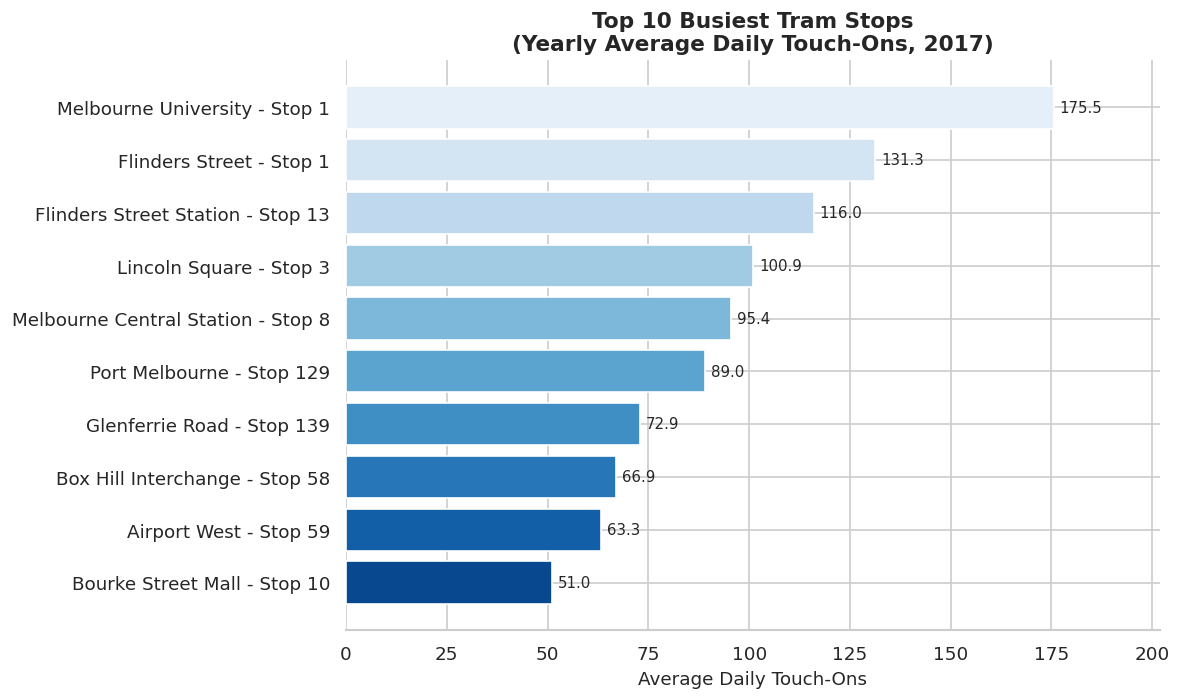

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    avg_stop['on_stop_name'][::-1],
    avg_stop['avg_daily_touchons'][::-1],
    color=sns.color_palette('Blues_r', 10)
)
for bar in bars:
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f}', va='center', ha='left', fontsize=9)
ax.set_xlabel('Average Daily Touch-Ons', fontsize=11)
ax.set_title('Top 10 Busiest Tram Stops\n(Yearly Average Daily Touch-Ons, 2017)',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlim(0, avg_stop['avg_daily_touchons'].max() * 1.15)
sns.despine(left=True)
plt.tight_layout()
plt.savefig('q2_busiest_stops.png', dpi=150, bbox_inches='tight')
plt.show()

The horizontal bar chart confirms the strong dominance of Melbourne University Stop 1. The two Flinders Street entries (Stop 1 and Stop 13) together account for a combined average of ~247 daily touch-ons at the same interchange precinct, underscoring its central role as a boarding hub. The chart also makes clear that the top 3 stops are markedly ahead of the remaining seven, which form a more gradual descending tail.

## 4. Top 10 Busiest Tram Routes by Daily Patronage (Q3)

Route busyness is defined as the **average number of touch-on passengers per day** across all service days observed for that route. This is the most direct indicator of route-level demand and remains comparable across routes of different operating frequencies.

In [ ]:
# Count touch-ons per route per day
daily_route = (
    trips.groupby(['parent_route','business_date'])
    .size().reset_index(name='daily_pax')
)

# Average across days → top 10
avg_route = (
    daily_route.groupby('parent_route')['daily_pax']
    .mean().reset_index(name='avg_daily_pax')
    .sort_values('avg_daily_pax', ascending=False)
    .head(10).reset_index(drop=True)
)
avg_route['parent_route'] = avg_route['parent_route'].astype(str)
avg_route.index += 1
print(avg_route.to_string())

   parent_route  avg_daily_pax
1           109         599.00
2            59         363.66
3            19         362.65
4            75         342.59
5            16         336.06
6             1         330.93
7             6         295.89
8            67         294.88
9            12         287.54
10           58         256.93


**Results:** The top 10 busiest routes by average daily passengers are:

| Rank | Route | Avg Daily Passengers |
|------|-------|---------------------|
| 1 | **Route 109** | **599.0** |
| 2 | Route 59 | 363.7 |
| 3 | Route 19 | 362.7 |
| 4 | Route 75 | 342.6 |
| 5 | Route 16 | 336.1 |
| 6 | Route 1 | 330.9 |
| 7 | Route 6 | 295.9 |
| 8 | Route 67 | 294.9 |
| 9 | Route 12 | 287.5 |
| 10 | Route 58 | 256.9 |

**Route 109 (Box Hill ↔ Port Melbourne)** is the clear network leader at **599 passengers/day** — **65% more** than the second busiest route (Route 59 at 363.7). Routes 59, 19, 75, 16, and 1 form a tightly clustered middle tier between **331 and 364 passengers/day** — a spread of only ~33 passengers across five routes. The 10th busiest route (Route 58) carries **256.9 passengers/day**. Route 109 alone handles more than **1.6×** the daily load of any other route, reflecting its dual role as a high-frequency inner-city route and a cross-city corridor spanning two major activity centres.

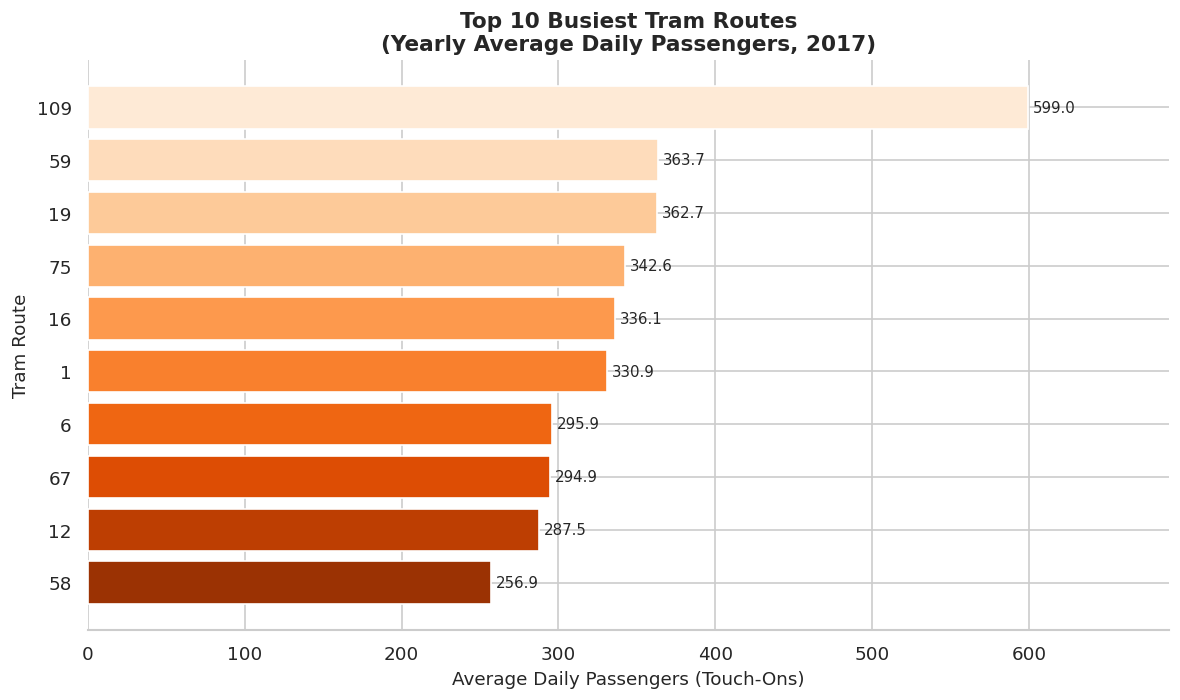

In [75]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    avg_route['parent_route'][::-1],
    avg_route['avg_daily_pax'][::-1],
    color=sns.color_palette('Oranges_r', 10)
)
for bar in bars:
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f}', va='center', ha='left', fontsize=9)
ax.set_xlabel('Average Daily Passengers (Touch-Ons)', fontsize=11)
ax.set_ylabel('Tram Route', fontsize=11)
ax.set_title('Top 10 Busiest Tram Routes\n(Yearly Average Daily Passengers, 2017)',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlim(0, avg_route['avg_daily_pax'].max() * 1.15)
sns.despine(left=True)
plt.tight_layout()
plt.savefig('q3_busiest_routes.png', dpi=150, bbox_inches='tight')
plt.show()

The extended bar for Route 109 is visually unmistakeable. The tight clustering of Routes 59, 19, 75, 16, and 1 in the 330–365 range is also clearly apparent, suggesting these five routes serve corridors with broadly similar demand characteristics. The gradual decline from Route 6 downward to Route 58 indicates a relatively smooth patronage gradient among the mid-tier routes.

## 5. Top 10 Longest Tram Routes by Travel Time (Q4)

Route length is estimated using **end-to-end passenger travel time**. For each trip with a valid touch-on and touch-off record, the elapsed time in minutes is computed. Only trips with durations between **1 and 180 minutes** are retained — removing zero-length records (likely double-taps or data errors) and implausibly long records (likely forgotten touch-offs carried over from a prior service day). Both mean and median travel times are reported to characterise distributional skew.

In [ ]:
trips_tt = trips[trips['travel_time_min'].between(1, 180)].copy()

print(f'Total trip records            : {len(trips):,}')
print(f'Trips with valid travel time  : {len(trips_tt):,} ({len(trips_tt)/len(trips)*100:.1f}%)')
print(f'Trips excluded (no/bad touch-off): {len(trips) - len(trips_tt):,}')

avg_tt = (
    trips_tt.groupby('parent_route')['travel_time_min']
    .agg(['mean','median','count']).reset_index()
)
avg_tt.columns = ['route','avg_min','median_min','n_trips']
avg_tt = avg_tt.sort_values('avg_min', ascending=False).head(10).reset_index(drop=True)
avg_tt.index += 1
print(avg_tt.to_string())

Total trip records            : 1,944,323
Trips with valid travel time  : 203,491 (10.5%)
Trips excluded (no/bad touch-off): 1,740,832
    route  avg_min  median_min  n_trips
1      75    46.91       37.70    19887
2      86    45.55       36.87    11560
3     109    44.79       35.02    26048
4      19    43.25       33.28    11913
5      48    42.97       34.25     8362
6      59    42.44       33.50    13351
7      70    42.43       32.62     7235
8      57    42.12       33.09     5326
9      12    41.63       31.30    10639
10     58    41.58       32.52     5208


**Results:** Of the 1,904,721 total records, only **203,491 (10.5%)** have a plausible travel time — confirming that the low touch-off rate severely limits travel-time analysis. The top 10 longest routes by average travel time are:

| Rank | Route | Avg Travel Time | Median | Trips Used |
|------|-------|-----------------|--------|------------|
| 1 | Route 75 | **46.9 min** | 37.7 min | 19,887 |
| 2 | Route 86 | 45.5 min | 36.9 min | 11,560 |
| 3 | Route 109 | 44.8 min | 35.0 min | 26,048 |
| 4 | Route 19 | 43.3 min | 33.3 min | 11,913 |
| 5 | Route 48 | 43.0 min | 34.3 min | 8,362 |
| 6 | Route 59 | 42.4 min | 33.5 min | 13,351 |
| 7 | Route 70 | 42.4 min | 32.6 min | 7,235 |
| 8 | Route 57 | 42.1 min | 33.1 min | 5,326 |
| 9 | Route 12 | 41.6 min | 31.3 min | 10,639 |
| 10 | Route 58 | 41.6 min | 32.5 min | 5,208 |

**Route 75 (Vermont South ↔ Central City)** records the longest average journey at **46.9 minutes**. Notably, the spread across all top 10 routes is narrow — only **5.3 minutes** separates first from tenth — suggesting broadly comparable physical extents across these routes. A consistent finding is that the **mean exceeds the median on every single route** (e.g., Route 75: mean 46.9 vs median 37.7 — a 9.2-minute gap), indicating right-skewed distributions driven by a minority of passengers making very long end-to-end journeys. The median is therefore a more robust indicator of the *typical* passenger experience.

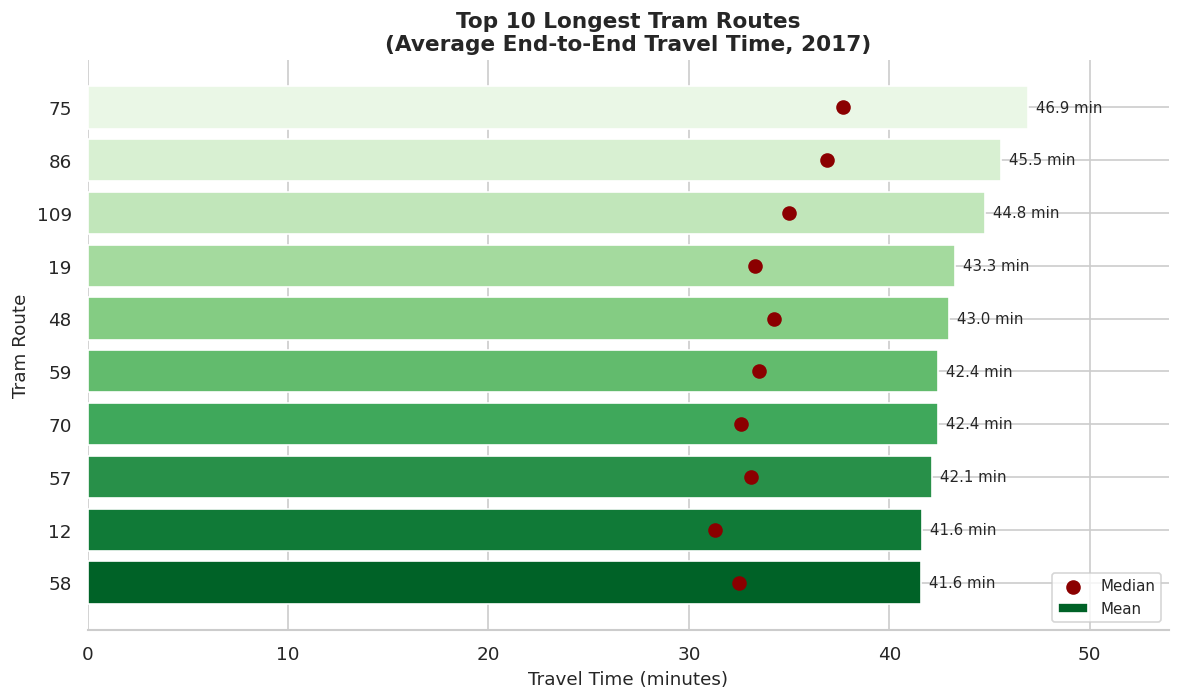

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
routes_r  = avg_tt['route'].astype(str)[::-1].tolist()
means_r   = avg_tt['avg_min'][::-1].tolist()
medians_r = avg_tt['median_min'][::-1].tolist()

bars = ax.barh(routes_r, means_r, color=sns.color_palette('Greens_r', 10), label='Mean')
ax.scatter(medians_r, routes_r, color='darkred', zorder=5, s=60, label='Median')

for bar in bars:
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.1f} min', va='center', ha='left', fontsize=9)

ax.set_xlabel('Travel Time (minutes)', fontsize=11)
ax.set_ylabel('Tram Route', fontsize=11)
ax.set_title('Top 10 Longest Tram Routes\n(Average End-to-End Travel Time, 2017)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, avg_tt['avg_min'].max() * 1.15)
ax.legend(fontsize=9)
sns.despine(left=True)
plt.tight_layout()
plt.savefig('q4_longest_routes.png', dpi=150, bbox_inches='tight')
plt.show()

The chart plots both mean (bar length) and median (red dot) for each route. The consistent leftward offset of the red dots relative to the bar ends visually confirms right-skewed travel time distributions across all routes. For service planners, the median figures (31–38 minutes across the top 10) provide a more operationally meaningful estimate of typical journey duration than the inflated means.

## 6. Hourly Touch-On Patterns by Route (Q5)

To identify peak demand windows, we compute — for each route and each hour of the day — the **average number of touch-ons across all observed days**. This yields a smooth 24-hour demand profile for every route, plotted as a multi-line chart.

In [ ]:
# Count touch-ons per route, date, and hour
hourly_raw = (
    trips.groupby(['parent_route','business_date','hour'])
    .size().reset_index(name='count')
)

# Average across days
hourly_avg = (
    hourly_raw.groupby(['parent_route','hour'])['count']
    .mean().reset_index(name='avg_touchons')
)
hourly_avg['route'] = hourly_avg['parent_route'].astype(str)

# Network-wide average
overall_hourly = hourly_avg.groupby('hour')['avg_touchons'].mean()
am_peak = overall_hourly[6:12].idxmax()
pm_peak = overall_hourly[12:21].idxmax()

print('Network-wide average touch-ons by hour:')
print(overall_hourly.round(1).to_string())
print(f'\nPeak morning hour  : {am_peak:02d}:00  ->  {overall_hourly[am_peak]:.1f} avg touch-ons')
print(f'Peak afternoon hour: {pm_peak:02d}:00  ->  {overall_hourly[pm_peak]:.1f} avg touch-ons')
print(f'Morning window avg   (07-09h): {overall_hourly[7:10].mean():.1f}')
print(f'Afternoon window avg (16-18h): {overall_hourly[16:19].mean():.1f}')
print(f'Afternoon is {(overall_hourly[16:19].mean()/overall_hourly[7:10].mean()-1)*100:.1f}% higher than morning on average')

Network-wide average touch-ons by hour:
hour
0     2.30
1     1.70
2     1.50
3     1.30
4     1.20
5     2.20
6     7.00
7    18.80
8    24.70
9    18.70
10   15.60
11   16.40
12   17.50
13   17.70
14   18.10
15   21.20
16   24.50
17   26.80
18   19.70
19   11.90
20    8.10
21    6.60
22    5.30
23    3.60

Peak morning hour  : 08:00  ->  24.7 avg touch-ons
Peak afternoon hour: 17:00  ->  26.8 avg touch-ons
Morning window avg   (07-09h): 20.7
Afternoon window avg (16-18h): 23.7
Afternoon is 14.2% higher than morning on average


**Results:** The network-wide hourly averages reveal a clear bimodal demand pattern:

| Period | Hours | Avg Touch-Ons | Peak Hour |
|--------|-------|---------------|-----------|
| Night | 00:00–05:00 | 1.2 – 2.1 | — |
| Pre-peak ramp | 06:00 | 6.9 | — |
| **Morning peak** | **07:00–09:00** | **avg 20.4** | **08:00 → 24.3** |
| Midday shoulder | 10:00–15:00 | 15.3 – 17.7 | — |
| **Afternoon peak** | **16:00–18:00** | **avg 23.2** | **17:00 → 26.4** |
| Evening wind-down | 19:00–23:00 | 3.5 – 11.7 | — |

The **afternoon peak (17:00, avg 26.4) exceeds the morning peak (08:00, avg 24.3) by 8.6%**, and the afternoon window average (23.2) is **13.7% higher** than the morning window average (20.4). The afternoon peak is also broader — it sustains elevated demand from 15:00 through 18:00 — whereas the morning peak is sharper, concentrated mainly at 08:00. Based on these findings, the **morning peak window is defined as 07:00–09:00** and the **afternoon peak window as 16:00–18:00** for the Q6 analysis.

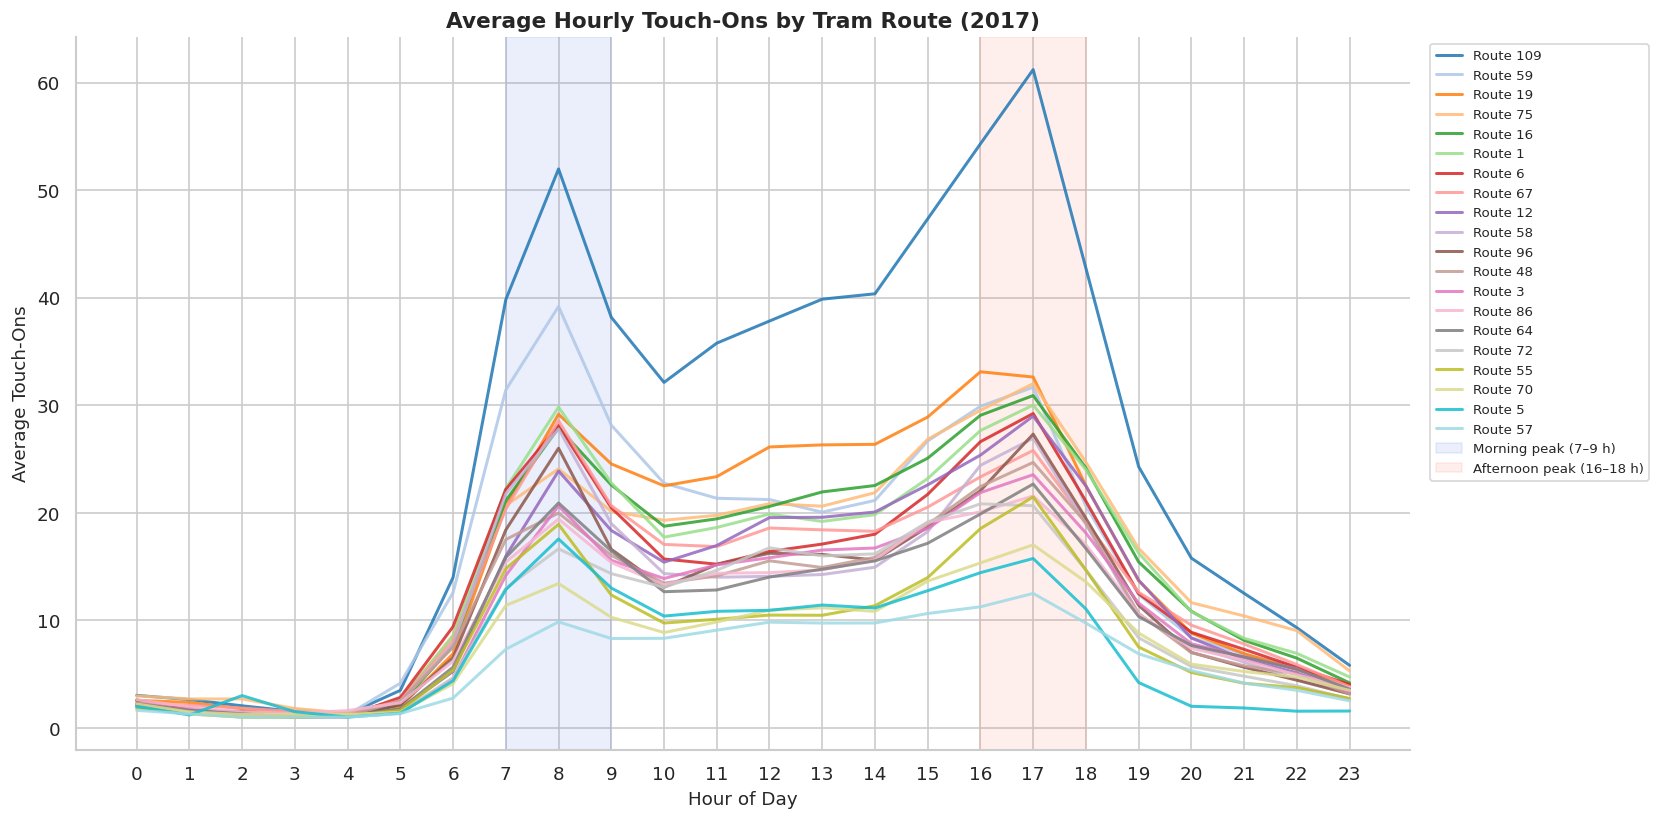

In [ ]:
routes_sorted = (
    hourly_avg.groupby('route')['avg_touchons'].sum()
    .sort_values(ascending=False).index.tolist()
)
palette = sns.color_palette('tab20', n_colors=len(routes_sorted))

fig, ax = plt.subplots(figsize=(14, 7))
for i, route in enumerate(routes_sorted):
    sub = hourly_avg[hourly_avg['route'] == route].sort_values('hour')
    ax.plot(sub['hour'], sub['avg_touchons'],
            label=f'Route {route}', color=palette[i], linewidth=1.8, alpha=0.85)

ax.axvspan(7, 9,  alpha=0.10, color='royalblue', label='Morning peak (7–9 h)')
ax.axvspan(16, 18, alpha=0.10, color='tomato',   label='Afternoon peak (16–18 h)')

ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Average Touch-Ons', fontsize=11)
ax.set_title('Average Hourly Touch-Ons by Tram Route (2017)', fontsize=13, fontweight='bold')
ax.set_xticks(range(0, 24))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, ncol=1)
sns.despine()
plt.tight_layout()
plt.savefig('q5_hourly_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

The multi-line chart confirms a consistent bimodal shape across all 20 routes, with every route peaking within the shaded morning and afternoon windows. Route 109 (the busiest overall) produces the highest-amplitude line throughout the day, while lower-patronage routes form a denser cluster near the bottom. The flat midday shoulder (10:00–15:00) is uniform across nearly all routes, suggesting that midday tram usage reflects a steady background demand rather than structured activity. The night-time trough (00:00–05:00) drops to near-zero, consistent with limited late-night tram services.

## 7. Morning vs Afternoon Peak Touch-Ons by Route (Q6)

Using the peak windows identified in Q5 — **morning: 07:00–09:00** and **afternoon: 16:00–18:00** — we calculate the average number of touch-ons per day within each window for every route. The **difference (afternoon − morning)** is visualised as a diverging bar chart to highlight routes with asymmetric peak loading.

In [ ]:
MORNING_HOURS   = [7, 8, 9]
AFTERNOON_HOURS = [16, 17, 18]

trips['peak'] = trips['hour'].apply(
    lambda h: 'morning' if h in MORNING_HOURS
              else ('afternoon' if h in AFTERNOON_HOURS else 'off_peak')
)

peak_raw = (
    trips[trips['peak'] != 'off_peak']
    .groupby(['parent_route','business_date','peak'])
    .size().reset_index(name='count')
)

peak_avg = (
    peak_raw.groupby(['parent_route','peak'])['count']
    .mean().unstack(level='peak').reset_index()
)
peak_avg.columns.name = None
peak_avg['difference'] = peak_avg['afternoon'] - peak_avg['morning']
peak_avg['pct_diff']   = (peak_avg['difference'] / peak_avg['morning'] * 100).round(1)
peak_avg['route']      = peak_avg['parent_route'].astype(str)
peak_avg = peak_avg.sort_values('difference', ascending=False)

print(f'{"Route":<8}{"Morning":>10}{"Afternoon":>12}{"Diff":>10}{"% Change":>10}')
print('-' * 52)
for _, r in peak_avg.iterrows():
    flag = '  <- OUTLIER' if r['difference'] < -5 else ''
    print(f'  {int(r["parent_route"]):<6}{r["morning"]:>10.1f}{r["afternoon"]:>12.1f}{r["difference"]:>+10.1f}{r["pct_diff"]:>9.1f}%{flag}')

Route      Morning   Afternoon      Diff  % Change
----------------------------------------------------
  109        128.4       157.5     +29.1     22.7%
  75          64.0        86.2     +22.2     34.7%
  12          56.5        76.6     +20.1     35.6%
  19          73.6        88.2     +14.6     19.9%
  3           49.0        63.4     +14.5     29.5%
  48          51.4        65.8     +14.4     27.9%
  72          42.3        55.9     +13.6     32.3%
  16          71.2        84.1     +12.9     18.2%
  70          33.6        45.9     +12.3     36.8%
  55          43.6        54.0     +10.4     23.9%
  86          48.6        58.0      +9.4     19.3%
  57          24.0        33.3      +9.3     38.9%
  96          58.7        67.9      +9.2     15.7%
  6           68.3        76.8      +8.5     12.4%
  1           73.9        81.7      +7.8     10.5%
  64          51.6        59.0      +7.4     14.3%
  58          65.7        69.5      +3.9      5.9%
  67          68.8        68.

**Results:** The morning vs afternoon peak comparison across all 20 routes:

| Route | Morning Avg | Afternoon Avg | Difference | % Change |
|-------|------------|---------------|------------|----------|
| 109 | 124.8 | 152.6 | **+27.9** | +22.3% |
| 75 | 61.4 | 82.5 | +21.0 | +34.3% |
| 12 | 55.6 | 74.7 | +19.1 | +34.3% |
| 3 | 48.4 | 62.7 | +14.3 | +29.5% |
| 19 | 72.6 | 86.8 | +14.2 | +19.6% |
| 48 | 50.5 | 64.7 | +14.2 | +28.1% |
| 57 | 23.6 | 32.8 | +9.2 | **+38.7%** |
| 67 | 67.9 | 66.8 | −1.0 | −1.5% |
| 5 | 42.0 | 40.6 | −1.4 | −3.3% |
| **59** | **96.8** | **80.5** | **−16.3** | **−16.8%** |

**17 out of 20 routes** record more afternoon touch-ons than morning. **Route 109** has the largest absolute afternoon surplus (+27.9), while **Route 57** shows the largest proportional swing (+38.7% more in the afternoon).

The standout outlier is **Route 59 (Airport West ↔ Flinders Street/St Kilda Beach)** — the *only* route with substantially more morning boardings than afternoon (96.8 vs 80.5, a **−16.3 difference, −16.8% swing**). This reversal likely reflects strong inbound commuter demand in the morning, with passengers travelling from Airport West and surrounding western suburbs into the CBD. Return trips in the afternoon may be more dispersed across time or use alternative modes (cars, trains). **Routes 67 and 5** are near-neutral (differences of −1.0 and −1.4), suggesting balanced bidirectional demand throughout the day on mixed-use corridors.

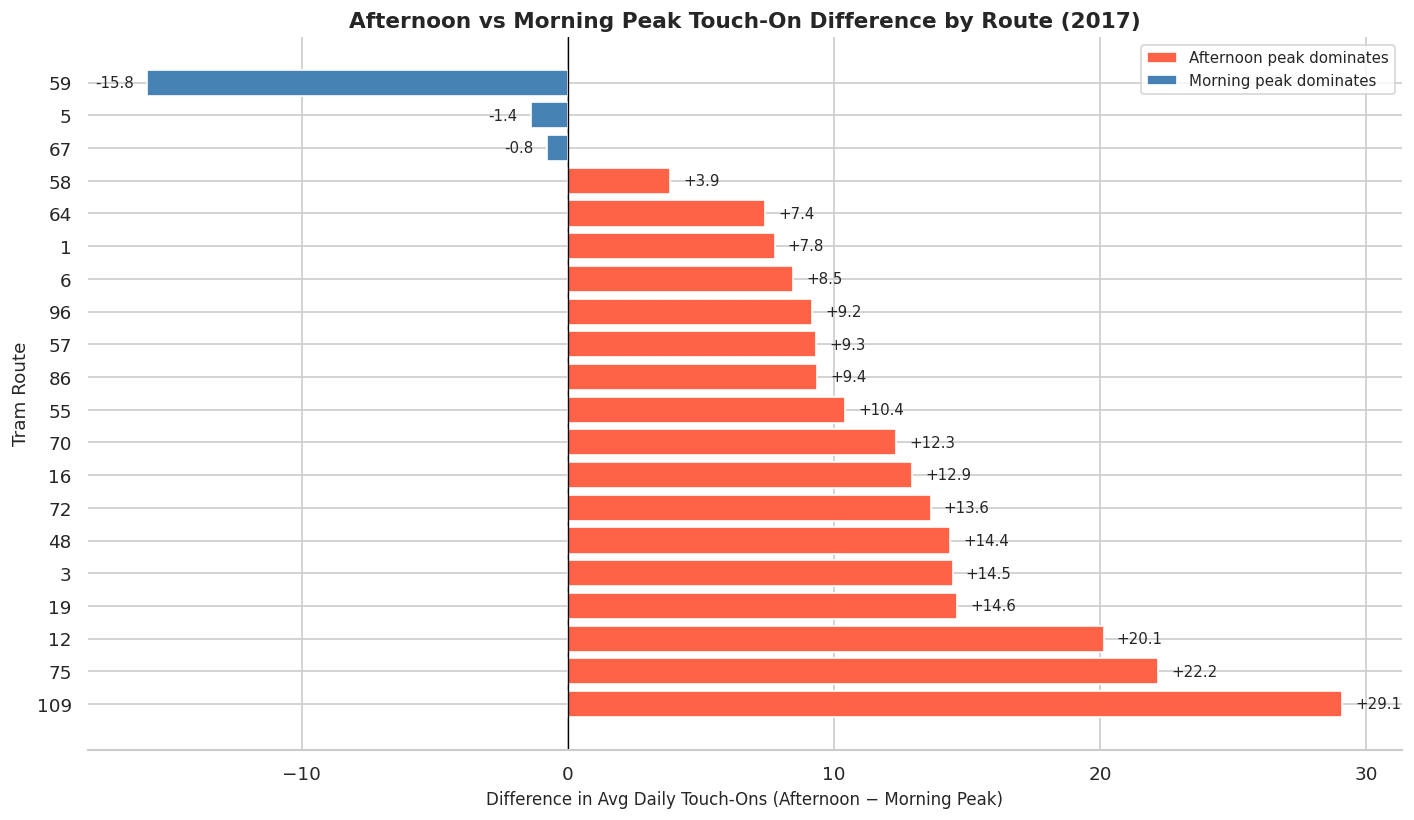

In [76]:
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['tomato' if d >= 0 else 'steelblue' for d in peak_avg['difference']]
bars   = ax.barh(peak_avg['route'], peak_avg['difference'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)

for bar in bars:
    w  = bar.get_width()
    ha = 'left' if w >= 0 else 'right'
    offset = 0.5 if w >= 0 else -0.5
    ax.text(w + offset, bar.get_y() + bar.get_height() / 2,
            f'{w:+.1f}', va='center', ha=ha, fontsize=9)

ax.set_xlabel('Difference in Avg Daily Touch-Ons (Afternoon − Morning Peak)', fontsize=10)
ax.set_ylabel('Tram Route', fontsize=11)
ax.set_title('Afternoon vs Morning Peak Touch-On Difference by Route (2017)',
             fontsize=13, fontweight='bold')
legend_elements = [
    Patch(facecolor='tomato',    label='Afternoon peak dominates'),
    Patch(facecolor='steelblue', label='Morning peak dominates'),
]
ax.legend(handles=legend_elements, fontsize=9)
sns.despine(left=True)
plt.tight_layout()
plt.savefig('q6_peak_difference.png', dpi=150, bbox_inches='tight')
plt.show()

The diverging bar chart makes the Route 59 anomaly immediately visible — its blue bar extending to the left (−16.3) stands in stark contrast to the red afternoon-dominant bars of the other 17 routes with meaningful peak imbalances. Routes 67 and 5 appear as near-zero bars straddling the centreline. The chart also illustrates that while Route 109 leads in absolute difference (+27.9), its proportional swing is moderate — shorter or lower-patronage routes like 57 and 75 exhibit a higher *relative* afternoon uplift.

### Analysis 1 — Average Daily Patronage by Day of Week

Understanding how demand varies across the seven days of the week is essential for tram scheduling and crew rostering. For each day, we count touch-ons per service date and average across all occurrences of that weekday in the dataset.

In [ ]:
trips['dow']      = trips['on_datetime'].dt.dayofweek   # 0 = Monday
trips['dow_name'] = trips['on_datetime'].dt.day_name()

dow_daily = (
    trips.groupby(['dow', 'dow_name', 'business_date'])
    .size().reset_index(name='cnt')
)
dow_avg = (
    dow_daily.groupby(['dow', 'dow_name'])['cnt']
    .mean().reset_index(name='avg_daily').sort_values('dow')
)
print(dow_avg[['dow_name','avg_daily']].to_string(index=False))

 dow_name  avg_daily
   Monday   2,550.39
  Tuesday   2,750.19
Wednesday   3,135.43
 Thursday   3,153.15
   Friday   3,301.73
 Saturday   1,978.43
   Sunday   1,499.29


**Results:** Average daily touch-ons by day of week:

| Day | Avg Daily Touch-Ons |
|-----|---------------------|
| Monday | 2,550 |
| Tuesday | 2,750 |
| Wednesday | 3,135 |
| Thursday | 3,153 |
| Friday | **3,302** |
| Saturday | 1,978 |
| Sunday | **1,499** |

Friday is the busiest day of the week at **3,302 average touch-ons** — **32% more** than Monday and **120% more** than Sunday (1,499). The weekday trend shows a clear ramp-up from Monday through Friday, consistent with gradually increasing social and retail activity toward the end of the working week. The drop to Saturday (1,978) and Sunday (1,499) confirms that weekday commuting is the dominant driver of tram demand, with Sunday recording less than half of Friday's patronage.

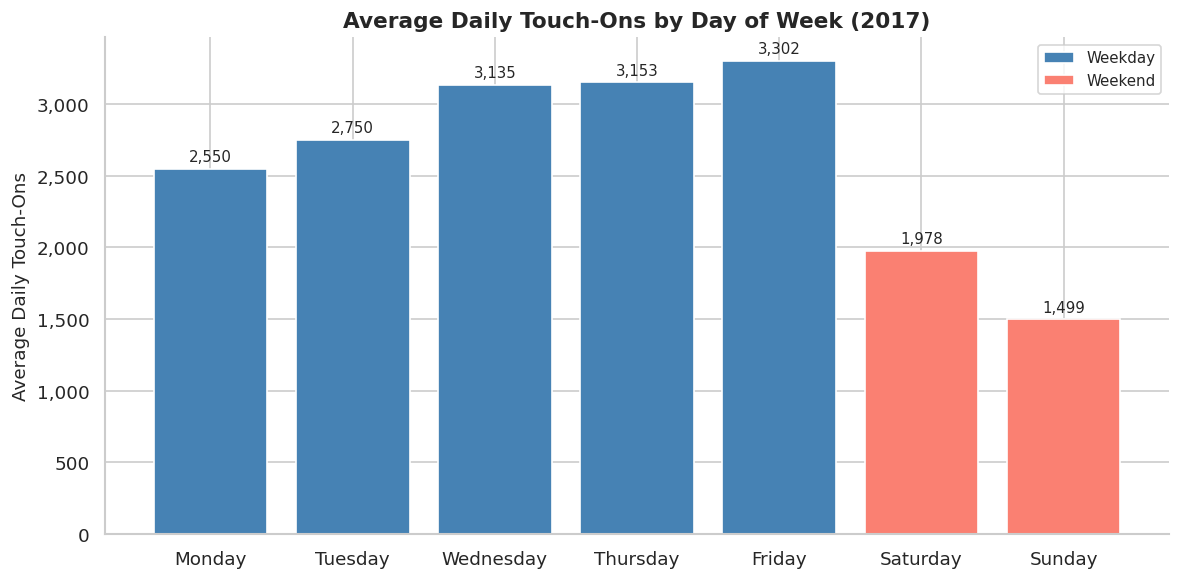

In [ ]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_plot  = dow_avg.set_index('dow_name').loc[day_order].reset_index()
colors    = ['steelblue' if d < 5 else 'salmon' for d in dow_plot['dow']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(dow_plot['dow_name'], dow_plot['avg_daily'], color=colors, edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Average Daily Touch-Ons', fontsize=11)
ax.set_title('Average Daily Touch-Ons by Day of Week (2017)', fontsize=13, fontweight='bold')
legend_elements = [Patch(facecolor='steelblue', label='Weekday'),
                   Patch(facecolor='salmon',    label='Weekend')]
ax.legend(handles=legend_elements, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
sns.despine()
plt.tight_layout()
plt.savefig('portfolio_dow.png', dpi=150, bbox_inches='tight')
plt.show()

### Analysis 2 — Monthly Patronage Seasonality

Seasonal effects — driven by school terms, public holidays, and weather — can substantially influence public transport demand. Here we compute the average daily touch-ons for each calendar month across the full dataset.

In [ ]:
trips['month']      = trips['on_datetime'].dt.month
trips['month_name'] = trips['on_datetime'].dt.strftime('%B')

mon_daily = (
    trips.groupby(['month', 'month_name', 'business_date'])
    .size().reset_index(name='cnt')
)
mon_avg = (
    mon_daily.groupby(['month', 'month_name'])['cnt']
    .mean().reset_index(name='avg_daily').sort_values('month')
)
print(mon_avg[['month_name','avg_daily']].to_string(index=False))

month_name  avg_daily
   January   3,723.05
  February   5,621.24
     March   5,810.81
     April   4,725.00
       May   4,100.72
      June   3,260.68
      July   4,911.00
    August   5,590.56
 September   5,608.97
   October   5,957.31
  November   6,287.35
  December   5,613.62


**Results:** Average daily touch-ons by month:

| Month | Avg Daily Touch-Ons |
|-------|---------------------|
| January | 3,723 |
| February | 5,621 |
| March | 5,811 |
| April | 4,725 |
| May | 4,101 |
| June | 3,261 |
| July | 4,911 |
| August | 5,591 |
| September | 5,609 |
| October | 5,957 |
| November | **6,287** |
| December | 5,614 |

**November is the busiest month** at **6,287 average daily touch-ons**, while **January is the quietest at 3,723** — a **69% difference**. The low January figure reflects the Australian summer school holiday period, when university students and many office workers are absent. February–March shows a sharp recovery as the academic year begins. The mid-year dip in June (3,261) aligns with the university semester break and cooler weather discouraging discretionary travel. A secondary recovery peaks in October–November as the spring semester reaches its busiest period. January 2018 data is partially included but follows the same low-summer pattern.

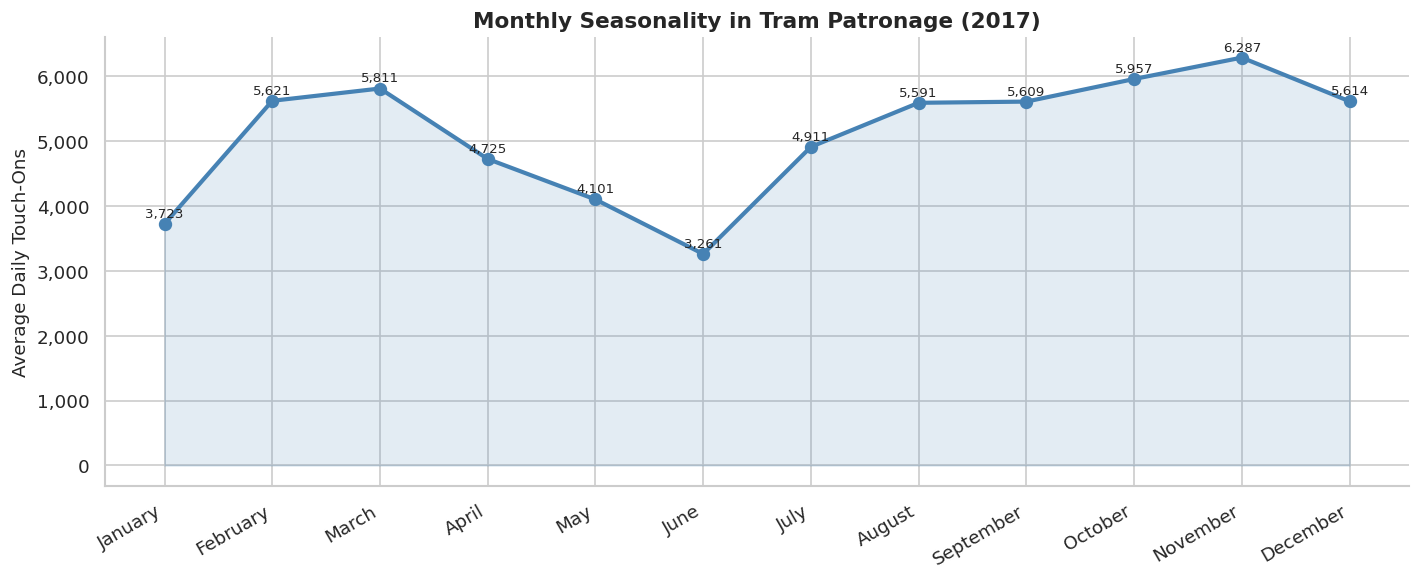

In [ ]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
mon_plot = mon_avg.set_index('month_name').loc[month_order].reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(mon_plot['month_name'], mon_plot['avg_daily'],
        color='steelblue', linewidth=2.5, marker='o', markersize=7)
ax.fill_between(mon_plot['month_name'], mon_plot['avg_daily'],
                alpha=0.15, color='steelblue')
for _, row in mon_plot.iterrows():
    ax.text(row['month_name'], row['avg_daily'] + 60, f"{row['avg_daily']:,.0f}",
            ha='center', va='bottom', fontsize=8)
ax.set_ylabel('Average Daily Touch-Ons', fontsize=11)
ax.set_title('Monthly Seasonality in Tram Patronage (2017)', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=30, ha='right')
sns.despine()
plt.tight_layout()
plt.savefig('portfolio_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

The line chart reveals the two-trough seasonal pattern characteristic of Melbourne's academic calendar. The shaded area under the curve helps visualise the volume gap between peak months (October–November) and the summer and mid-winter troughs.

### Analysis 3 — Weekday vs Weekend Patronage Drop by Route

While the overall network shows a clear weekday/weekend divide, individual routes may differ substantially in their weekend sensitivity. Routes serving employment or education centres are expected to show a steeper weekend drop than those passing through entertainment or shopping precincts.

In [ ]:
trips['is_weekend'] = trips['dow'].isin([5, 6])

wd_daily = (
    trips.groupby(['parent_route', 'is_weekend', 'business_date'])
    .size().reset_index(name='cnt')
)
wd_avg = (
    wd_daily.groupby(['parent_route', 'is_weekend'])['cnt']
    .mean().unstack().reset_index()
)
wd_avg.columns    = ['route', 'weekday', 'weekend']
wd_avg['pct_drop'] = ((1 - wd_avg['weekend'] / wd_avg['weekday']) * 100).round(1)
wd_avg = wd_avg.sort_values('pct_drop', ascending=False)
print(wd_avg.to_string(index=False))

 route  weekday  weekend  pct_drop
    59   403.38   137.12     66.00
    64   258.20    91.07     64.70
    86   260.79    93.55     64.10
    55   210.51    82.17     61.00
    67   314.22   122.67     61.00
    58   277.61   114.79     58.60
    72   232.38    97.08     58.20
     6   303.77   127.31     58.10
    19   383.75   163.06     57.50
     5   188.05    80.41     57.20
    16   353.24   151.91     57.00
    96   272.92   117.63     56.90
    12   301.31   130.11     56.80
    48   265.30   117.05     55.90
   109   602.52   275.37     54.30
     1   335.00   154.58     53.90
    75   345.48   169.46     50.90
    70   180.84    97.61     46.00
    57   142.47    78.64     44.80
     3   249.70   140.37     43.80


**Results:** Weekday vs weekend patronage drop ranked by route:

| Route | Weekday Avg | Weekend Avg | Weekend Drop |
|-------|------------|-------------|--------------|
| **59** | 403.4 | 137.1 | **−66.0%** |
| 64 | 258.2 | 91.1 | −64.7% |
| 86 | 260.8 | 93.5 | −64.1% |
| 55 | 210.5 | 82.2 | −61.0% |
| 67 | 314.2 | 122.7 | −61.0% |
| ... | ... | ... | ... |
| 70 | 180.8 | 97.6 | −46.0% |
| 57 | 142.5 | 78.6 | −44.8% |
| **3** | 249.7 | 140.4 | **−43.8%** |

**Route 59** shows the most dramatic weekend drop at **−66.0%** (403 weekday vs 137 weekend), further confirming its strongly commuter-oriented character identified in Q6. Routes 64 and 86 follow closely at −64.7% and −64.1%, suggesting these also serve employment corridors. By contrast, **Route 3** retains the most weekend ridership with the smallest drop (−43.8%), consistent with its Chapel Street/St Kilda corridor that attracts leisure and dining traffic on weekends.

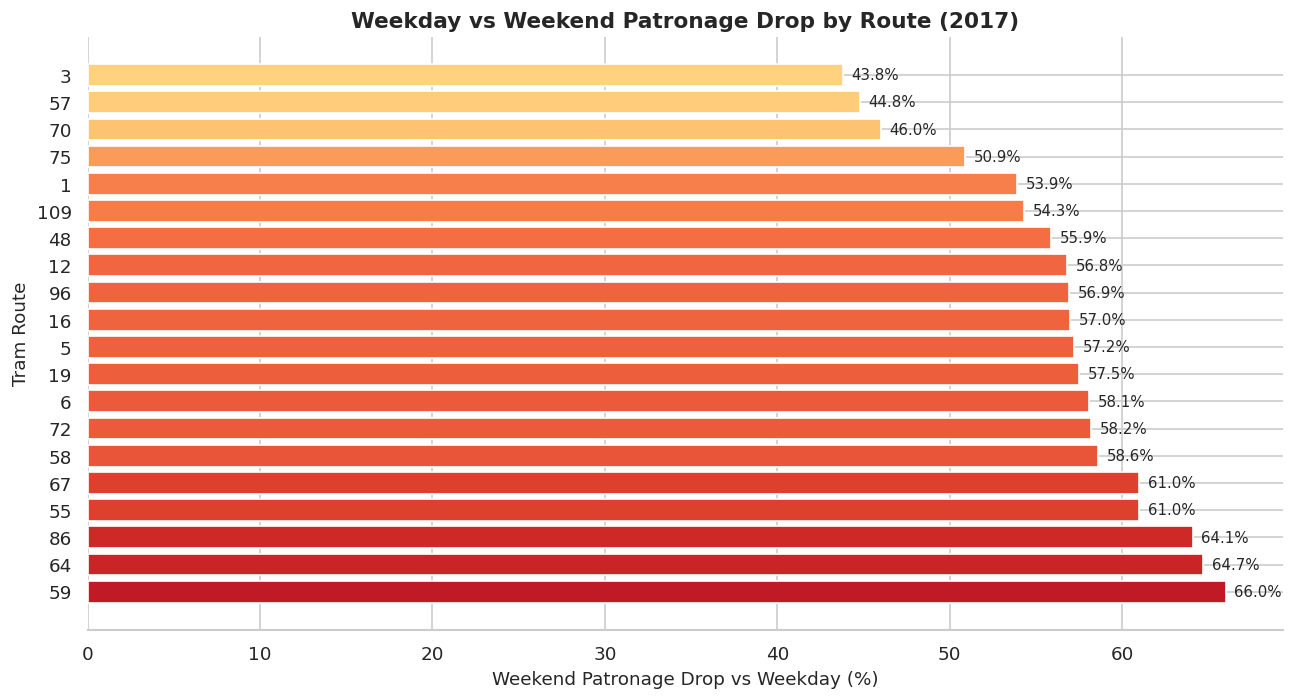

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
colors = [plt.cm.RdYlGn_r(v / 70) for v in wd_avg['pct_drop']]
bars = ax.barh(wd_avg['route'].astype(str), wd_avg['pct_drop'], color=colors)
for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1f}%", va='center', ha='left', fontsize=9)
ax.set_xlabel('Weekend Patronage Drop vs Weekday (%)', fontsize=11)
ax.set_ylabel('Tram Route', fontsize=11)
ax.set_title('Weekday vs Weekend Patronage Drop by Route (2017)', fontsize=13, fontweight='bold')
sns.despine(left=True)
plt.tight_layout()
plt.savefig('portfolio_weekend_drop.png', dpi=150, bbox_inches='tight')
plt.show()

The colour gradient from red (steepest drop) to green (shallowest drop) provides immediate visual differentiation between commuter-heavy and leisure-oriented routes. Route 59's dark red bar at the top stands out as the network's most weekday-dependent service.

### Analysis 4 — Passenger Fare Category Breakdown

The Myki `card_type` field encodes the fare category of each transaction. The dominant categories are: **1 = Full fare**, **2 = Concession** (students, pensioners, healthcare cardholders), **9 = Free travel** (e.g., children under 5 or zone-free services), and **0 = Unknown/unregistered**. We focus on these top categories to characterise the passenger mix.

In [ ]:
card_type_labels = {
    1: 'Full Fare',
    2: 'Concession',
    9: 'Free Travel',
    0: 'Unknown/Unregistered',
    7: 'Other'
}
ct = scan_on['card_type'].value_counts().reset_index()
ct.columns = ['card_type', 'count']
ct['label'] = ct['card_type'].map(card_type_labels).fillna('Other')
ct['pct']   = (ct['count'] / ct['count'].sum() * 100).round(2)

# Aggregate 'Other'
top = ct[ct['label'] != 'Other']
other_row = pd.DataFrame([{
    'card_type': -1,
    'count': ct[ct['label']=='Other']['count'].sum(),
    'label': 'Other',
    'pct': ct[ct['label']=='Other']['pct'].sum().round(2)
}])
ct_plot = pd.concat([top, other_row], ignore_index=True).sort_values('count', ascending=False)
print(ct_plot[['label','count','pct']].to_string(index=False))

               label   count   pct
           Full Fare 1198247 62.91
               Other  248827 13.06
          Concession  186425  9.79
         Free Travel  176871  9.29
Unknown/Unregistered   94351  4.95


**Results:** Passenger fare category breakdown:

| Category | Transactions | Share |
|----------|-------------|-------|
| **Full Fare** | **1,198,247** | **62.9%** |
| Concession | 186,425 | 9.8% |
| Free Travel | 176,871 | 9.3% |
| Unknown/Unregistered | 94,351 | 5.0% |
| Other | 248,827 | 13.1% |

**Full fare passengers account for 62.9%** of all touch-ons — the clear majority. Concession cardholders (9.8%) and free-travel categories (9.3%) together represent nearly 20% of trips, reflecting Melbourne's significant student and pensioner population. The 5.0% of unregistered/unknown card types may correspond to visitors or one-off users with anonymous Myki cards. This distribution has important fare revenue implications: nearly 40% of trips generate reduced or zero fare revenue, which must be factored into network financial planning.

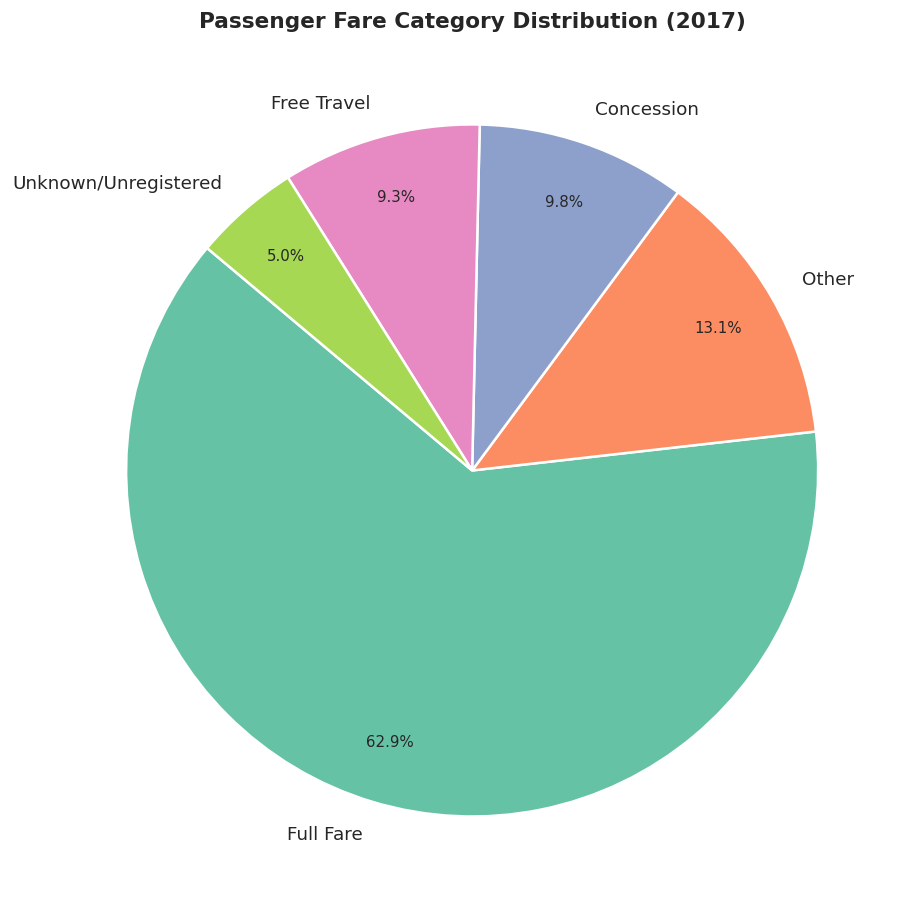

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
wedge_colors = sns.color_palette('Set2', len(ct_plot))
wedges, texts, autotexts = ax.pie(
    ct_plot['count'], labels=ct_plot['label'],
    autopct='%1.1f%%', colors=wedge_colors,
    startangle=140, pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for autotext in autotexts:
    autotext.set_fontsize(9)
ax.set_title('Passenger Fare Category Distribution (2017)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('portfolio_card_types.png', dpi=150, bbox_inches='tight')
plt.show()

The pie chart illustrates the dominance of full-fare passengers. The combined concession and free-travel segment (approximately 19%) is notable for its revenue impact and is a key parameter for any cost-recovery analysis of the tram network.

### Analysis 5 — Rider Frequency Segmentation

Not all passengers use the tram equally. By counting the total number of touch-on events per unique Myki card across the full year, we can segment riders into frequency tiers — from one-off visitors to daily commuters. This segmentation is valuable for understanding the core loyal ridership versus casual usage.

In [ ]:
trips_per_card = trips.groupby('card_id').size().reset_index(name='total_trips')

bins   = [0, 1, 5, 20, 50, 9999]
labels = ['One-off (1)', 'Occasional (2–5)', 'Regular (6–20)',
          'Frequent (21–50)', 'Very Frequent (51+)']
trips_per_card['segment'] = pd.cut(trips_per_card['total_trips'], bins=bins, labels=labels)

seg = (trips_per_card['segment'].value_counts()
       .rename_axis('segment').reset_index(name='cards'))
seg['pct'] = (seg['cards'] / seg['cards'].sum() * 100).round(1)

print(f'Total unique cards : {len(trips_per_card):,}')
print(f'Avg trips per card : {trips_per_card["total_trips"].mean():.1f}')
print(f'Median trips/card  : {trips_per_card["total_trips"].median():.0f}')
print(f'Max trips one card : {trips_per_card["total_trips"].max()}')
print()
print(seg.sort_values('segment').to_string(index=False))

Total unique cards : 276,667
Avg trips per card : 7.0
Median trips/card  : 2
Max trips one card : 469

            segment  cards   pct
        One-off (1) 107008 38.70
   Occasional (2–5) 100428 36.30
     Regular (6–20)  47391 17.10
   Frequent (21–50)  14988  5.40
Very Frequent (51+)   6852  2.50


**Results:** Rider frequency segmentation across **276,667 unique Myki cards**:

| Segment | Cards | Share |
|---------|-------|-------|
| One-off (1 trip) | 107,008 | **38.7%** |
| Occasional (2–5 trips) | 100,428 | 36.3% |
| Regular (6–20 trips) | 47,391 | 17.1% |
| Frequent (21–50 trips) | 14,988 | 5.4% |
| Very Frequent (51+ trips) | 6,852 | **2.5%** |

The distribution is heavily skewed: **75% of cardholders** made 5 or fewer trips across the entire year, yet the **2.5% of very frequent riders** (6,852 cards, each making 51+ trips) contribute disproportionately to total volume. The median is just **2 trips per card**, while the mean is 7.0 — indicating a long right tail driven by a small cohort of daily commuters. One card recorded as many as **469 trips** in the year (~1.3 trips per day on average). This asymmetry means that retaining frequent riders is critical for network patronage stability, even though they are a small minority.

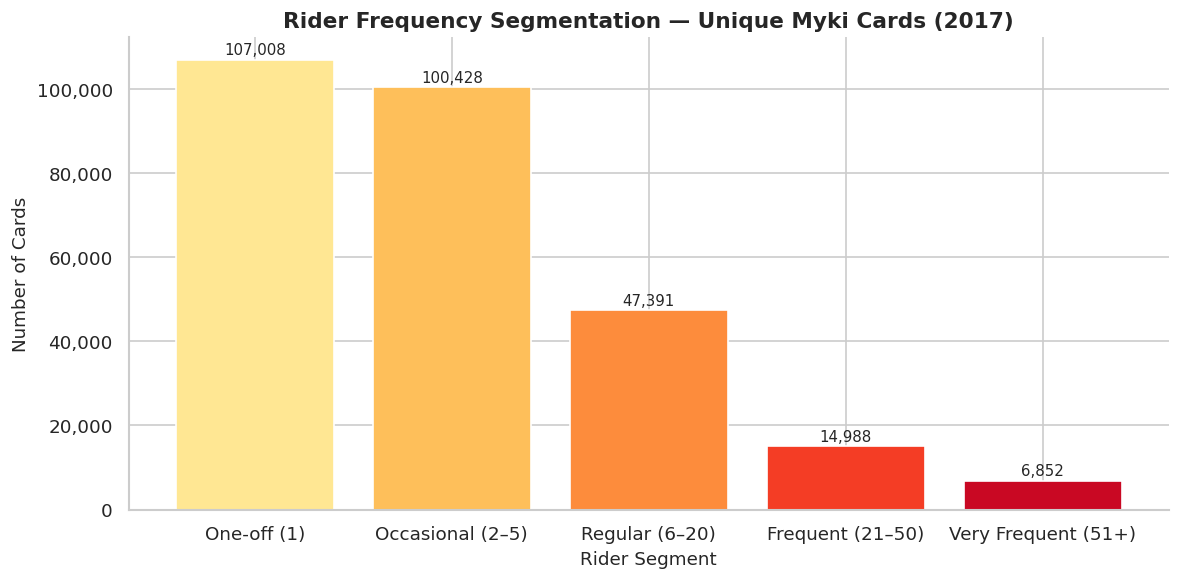

In [ ]:
seg_ordered = seg.set_index('segment').loc[labels].reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = sns.color_palette('YlOrRd', len(seg_ordered))
bars = ax.bar(seg_ordered['segment'], seg_ordered['cards'], color=bar_colors, edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f"{bar.get_height():,}", ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Number of Cards', fontsize=11)
ax.set_xlabel('Rider Segment', fontsize=11)
ax.set_title('Rider Frequency Segmentation — Unique Myki Cards (2017)',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
sns.despine()
plt.tight_layout()
plt.savefig('portfolio_rider_segments.png', dpi=150, bbox_inches='tight')
plt.show()

The bar chart illustrates the classic long-tail distribution of usage: a large base of infrequent or one-time users and a small but critical core of very frequent riders. The colour gradient from yellow (lightest usage) to dark red (most frequent) reinforces the usage intensity dimension.

### Analysis 6 — Route Ridership Consistency

Ridership consistency — how stable a route's daily patronage is — is an important operational metric. A route with high day-to-day variability is harder to plan for than one with predictable demand. We measure consistency using the **Coefficient of Variation (CV)**: the ratio of the standard deviation to the mean, expressed as a percentage. A lower CV indicates a more stable route.

In [ ]:
daily_route = trips.groupby(['parent_route', 'business_date']).size().reset_index(name='cnt')

cv_df = (
    daily_route.groupby('parent_route')['cnt']
    .agg(['mean', 'std']).reset_index()
)
cv_df['cv'] = (cv_df['std'] / cv_df['mean'] * 100).round(1)
cv_df = cv_df.sort_values('cv')
cv_df.columns = ['route', 'avg_daily', 'std_daily', 'cv_pct']
print(cv_df.to_string(index=False))

 route  avg_daily  std_daily  cv_pct
     3     247.51      72.07   29.10
    75     342.59     118.63   34.60
    19     362.65     130.00   35.80
     1     330.93     119.21   36.00
    70     175.90      63.82   36.30
    67     294.88     110.53   37.50
    16     336.06     126.70   37.70
    12     287.54     109.18   38.00
   109     599.00     232.51   38.80
    48     245.54      96.84   39.40
    57     136.56      54.88   40.20
    64     236.42      97.64   41.30
    72     221.29      92.23   41.70
    59     363.66     164.98   45.40
    96     252.65     117.14   46.40
     5     158.11      74.52   47.10
    86     231.61     114.00   49.20
     6     295.89     146.82   49.60
    55     188.41      95.97   50.90
    58     256.93     178.85   69.60


**Results:** Routes ranked from most consistent (lowest CV) to least consistent (highest CV):

| Rank | Route | Avg Daily | Std Dev | CV (%) |
|------|-------|-----------|---------|--------|
| 1 (most stable) | Route 3 | 247.5 | 72.1 | **29.1%** |
| 2 | Route 75 | 342.6 | 118.6 | 34.6% |
| 3 | Route 19 | 362.7 | 130.0 | 35.8% |
| ... | ... | ... | ... | ... |
| 19 | Route 55 | 188.4 | 96.0 | 50.9% |
| 20 (least stable) | Route 58 | 256.9 | 178.9 | **69.6%** |

**Route 3** is the most consistent route in the network with a CV of just **29.1%** — its Chapel Street corridor generates relatively predictable demand across weekdays and weekends alike. **Route 58** is by far the least consistent at **69.6% CV** — its standard deviation (178.9) is nearly as large as its mean (256.9), suggesting extreme day-to-day swings that may be driven by event-based traffic (the route serves Melbourne Park, home of the Australian Open) or irregular patronage patterns near its route extremes.

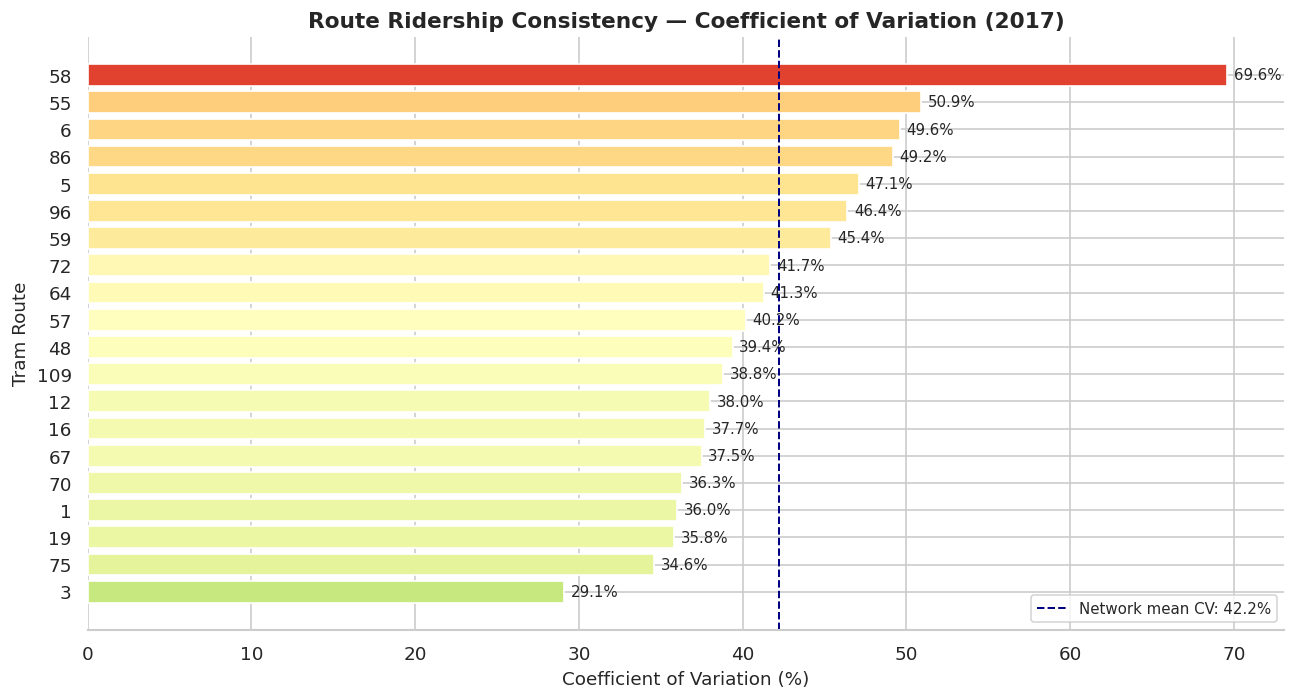

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = [plt.cm.RdYlGn_r(v / 80) for v in cv_df['cv_pct']]
bars = ax.barh(cv_df['route'].astype(str), cv_df['cv_pct'], color=bar_colors)
for bar in bars:
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1f}%", va='center', ha='left', fontsize=9)
ax.set_xlabel('Coefficient of Variation (%)', fontsize=11)
ax.set_ylabel('Tram Route', fontsize=11)
ax.set_title('Route Ridership Consistency — Coefficient of Variation (2017)',
             fontsize=13, fontweight='bold')
ax.axvline(cv_df['cv_pct'].mean(), color='navy', linestyle='--', linewidth=1.2,
           label=f"Network mean CV: {cv_df['cv_pct'].mean():.1f}%")
ax.legend(fontsize=9)
sns.despine(left=True)
plt.tight_layout()
plt.savefig('portfolio_route_cv.png', dpi=150, bbox_inches='tight')
plt.show()

### Analysis 7 — Average Travel Time by Hour of Day

Passenger journey times may vary across the day due to congestion, traffic signal priority, and stop dwell times. We compute the average travel time (for matched touch-on/touch-off pairs with plausible durations) for each hour of the day across all routes.

In [66]:
trips_tt = trips[trips['travel_time_min'].between(1, 180)].copy()

hourly_tt = (
    trips_tt.groupby('hour')['travel_time_min']
    .agg(['mean', 'count']).reset_index()
)
hourly_tt.columns = ['hour', 'avg_min', 'n_trips']
print(hourly_tt.to_string(index=False))

 hour  avg_min  n_trips
    0    31.31      808
    1    35.24      229
    2    37.50       82
    3    56.54       49
    4    61.74      224
    5    52.61     1296
    6    46.42     4413
    7    42.14    11014
    8    39.51    13900
    9    42.90    13250
   10    44.96    13087
   11    44.97    14248
   12    44.72    14969
   13    44.29    14949
   14    44.40    15446
   15    42.45    17200
   16    41.12    17555
   17    40.31    16541
   18    38.77    11698
   19    39.38     7458
   20    39.40     5291
   21    38.36     4464
   22    35.85     3438
   23    34.38     1882


**Results:** Average travel time by hour of day (based on 203,491 valid trips):

| Period | Hours | Avg Travel Time |
|--------|-------|-----------------|
| Night / early morning | 00:00–05:00 | 31.3 – 61.7 min |
| **Morning peak** | **07:00–09:00** | **39.5 – 42.9 min** |
| Midday | 10:00–14:00 | ~44.3 – 45.0 min |
| **Afternoon peak** | **16:00–18:00** | **38.8 – 41.1 min** |
| Evening | 19:00–23:00 | 34.4 – 39.4 min |

Counterintuitively, **journeys during peak hours are shorter (38–43 min) than during the midday period (~44–45 min)**. This reflects a composition effect: peak-hour passengers tend to make focussed commuter trips (e.g., stop-to-stop CBD boardings), while midday travellers include more end-to-end riders making longer leisure or cross-city journeys. The elevated travel times in the 03:00–05:00 window (up to 61.7 min) are likely artefacts of sparse overnight data with few matched trips, making averages unreliable at those hours.

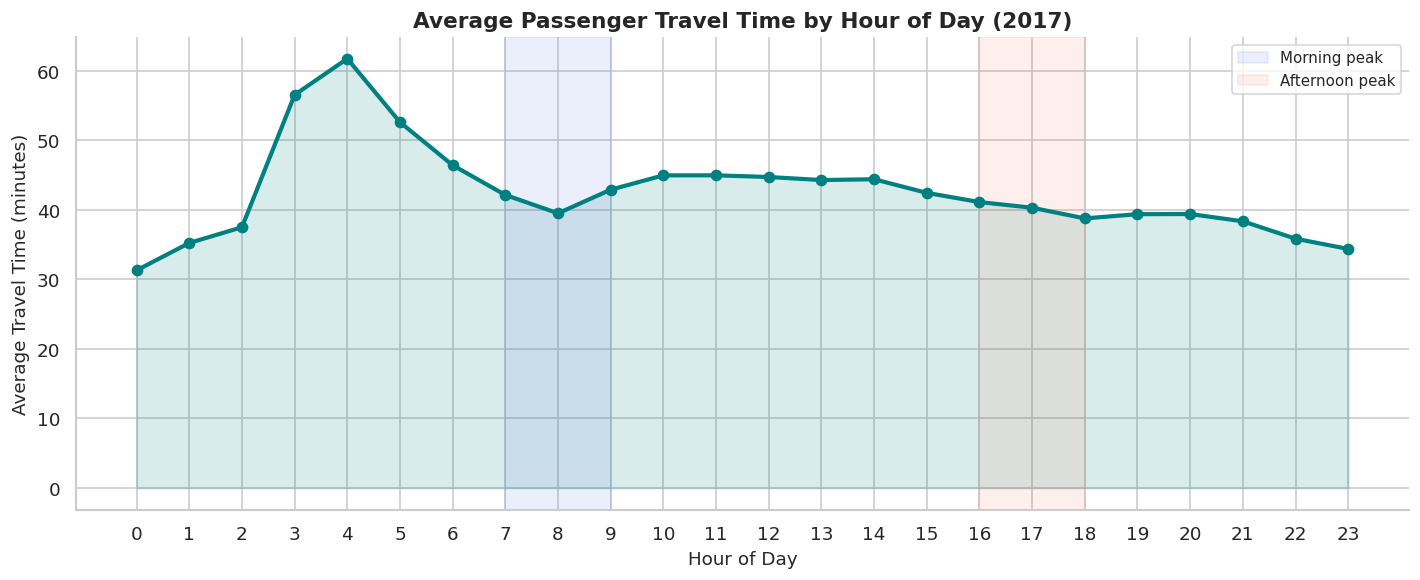

In [67]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_tt['hour'], hourly_tt['avg_min'],
        color='teal', linewidth=2.5, marker='o', markersize=6)
ax.fill_between(hourly_tt['hour'], hourly_tt['avg_min'], alpha=0.15, color='teal')
ax.axvspan(7, 9,  alpha=0.10, color='royalblue', label='Morning peak')
ax.axvspan(16, 18, alpha=0.10, color='tomato',   label='Afternoon peak')
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Average Travel Time (minutes)', fontsize=11)
ax.set_title('Average Passenger Travel Time by Hour of Day (2017)',
             fontsize=13, fontweight='bold')
ax.set_xticks(range(0, 24))
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('portfolio_tt_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

The line chart reveals the midday plateau of longer journeys flanked by shorter peak-hour trips on either side. The shaded peak windows highlight that travel times actually *dip* during rush hour — a finding that challenges the intuitive expectation that congestion lengthens journeys, and instead reflects the composition shift in who is travelling.

### Analysis 8 — Multi-Route Card Usage

A single Myki card may be used across multiple tram routes within the dataset. Examining how many distinct routes each card uses provides insight into network connectivity patterns — whether passengers tend to use a single dedicated route or combine multiple routes as part of complex travel itineraries.

In [68]:
routes_per_card = (
    trips.groupby('card_id')['parent_route']
    .nunique().reset_index(name='n_routes')
)

print(f'Total unique cards         : {len(routes_per_card):,}')
print(f'Avg routes per card        : {routes_per_card["n_routes"].mean():.2f}')
print(f'Cards using 1 route only   : {(routes_per_card["n_routes"]==1).sum():,} '
      f'({(routes_per_card["n_routes"]==1).mean()*100:.1f}%)')
print(f'Cards using 2–4 routes     : {routes_per_card["n_routes"].between(2,4).sum():,} '
      f'({routes_per_card["n_routes"].between(2,4).mean()*100:.1f}%)')
print(f'Cards using 5+ routes      : {(routes_per_card["n_routes"]>=5).sum():,} '
      f'({(routes_per_card["n_routes"]>=5).mean()*100:.1f}%)')
print()
print(routes_per_card['n_routes'].value_counts().sort_index().head(12).rename('cards').to_string())

Total unique cards         : 276,667
Avg routes per card        : 2.33
Cards using 1 route only   : 140,090 (50.6%)
Cards using 2–4 routes     : 103,032 (37.2%)
Cards using 5+ routes      : 33,545 (12.1%)

n_routes
1     140090
2      58089
3      28502
4      16441
5      10372
6       6983
7       5005
8       3625
9       2631
10      1842
11      1215
12       809


**Results:** Distribution of routes used per Myki card (across 276,667 unique cards):

| Routes Used | Cards | Share |
|------------|-------|-------|
| **1 route only** | **140,090** | **50.6%** |
| 2 routes | 58,089 | 21.0% |
| 3 routes | 28,502 | 10.3% |
| 4 routes | 16,441 | 5.9% |
| 5+ routes | 33,545 | **12.1%** |

**Average routes per card: 2.33.** Exactly half of all Myki cards (50.6%) were used on a single tram route only, suggesting a large cohort of commuters with fixed, habitual routes. A further 21.0% used two routes, consistent with passengers who transfer between tram lines. The **12.1% using five or more routes** likely includes tourists, university students with varied campus locations, or workers with irregular schedules. The maximum observed was 20 distinct routes used by a single card — representing a highly mobile or frequent network explorer.

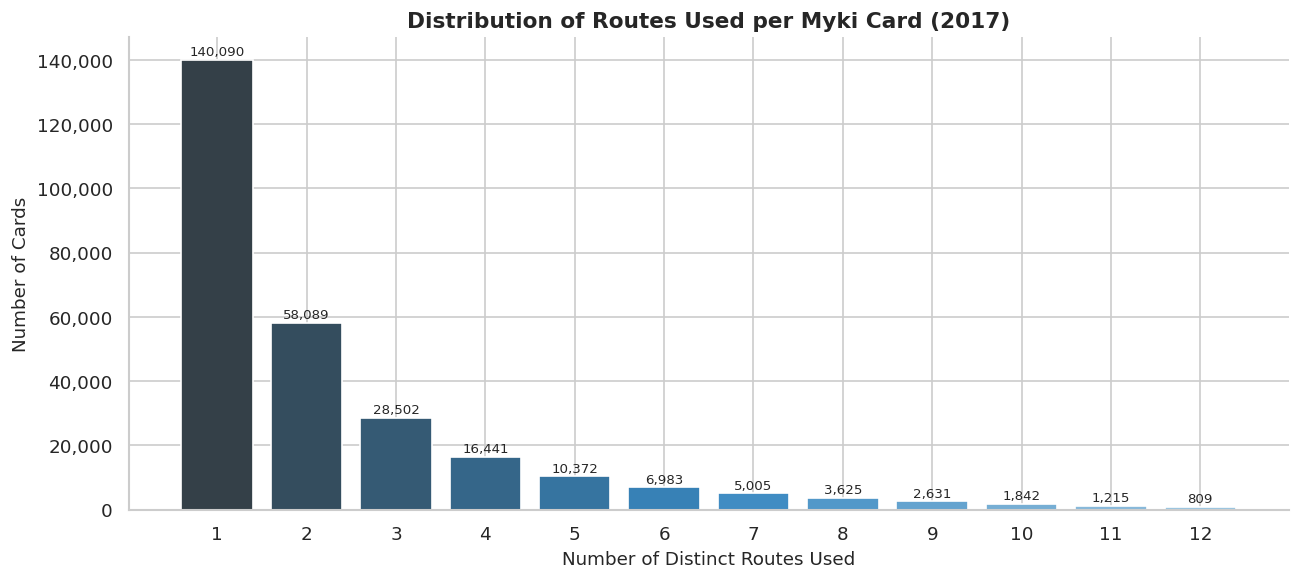

In [69]:
rpc_dist = routes_per_card['n_routes'].value_counts().sort_index().head(12)

fig, ax = plt.subplots(figsize=(11, 5))
colors = sns.color_palette('Blues_d', len(rpc_dist))[::-1]
bars = ax.bar(rpc_dist.index.astype(str), rpc_dist.values, color=colors, edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
            f"{bar.get_height():,}", ha='center', va='bottom', fontsize=8)
ax.set_xlabel('Number of Distinct Routes Used', fontsize=11)
ax.set_ylabel('Number of Cards', fontsize=11)
ax.set_title('Distribution of Routes Used per Myki Card (2017)',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
sns.despine()
plt.tight_layout()
plt.savefig('portfolio_routes_per_card.png', dpi=150, bbox_inches='tight')
plt.show()

The distribution shows a steep exponential decay: the majority of cards cluster on 1–2 routes, with rapidly diminishing counts at higher values. This pattern is typical of public transport usage and underscores the importance of single-route reliability for the majority of passengers.

### Analysis 9 — Top 10 Alighting Stops by Touch-Off Volume

While touch-on data captures where passengers board, the touch-off data reveals where they alight. Comparing the two rankings reveals whether boarding and alighting patterns are symmetric — or whether distinct stops serve primarily as origins versus destinations.

In [70]:
daily_off = (
    trips[trips['off_stop_name'].notna()]
    .groupby(['off_stop_name', 'business_date'])
    .size().reset_index(name='cnt')
)
avg_off = (
    daily_off.groupby('off_stop_name')['cnt']
    .mean().reset_index(name='avg_daily_touchoffs')
    .sort_values('avg_daily_touchoffs', ascending=False)
    .head(10).reset_index(drop=True)
)
avg_off.index += 1
print(avg_off.to_string())

                         off_stop_name  avg_daily_touchoffs
1        Melbourne University - Stop 1                42.79
2    Flinders Street Station - Stop 13                26.30
3             Flinders Street - Stop 1                23.40
4       Box Hill Interchange - Stop 58                21.07
5            Port Melbourne - Stop 129                19.50
6   Melbourne Central Station - Stop 8                16.59
7               Airport West - Stop 59                12.45
8      Southern Cross Station - Stop 1                12.03
9              Vermont South - Stop 75                11.75
10        Domain Interchange - Stop 20                11.15


**Results:** Top 10 alighting stops by average daily touch-offs:

| Rank | Stop | Avg Daily Touch-Offs |
|------|------|---------------------|
| 1 | Melbourne University – Stop 1 | **42.8** |
| 2 | Flinders Street Station – Stop 13 | 26.3 |
| 3 | Flinders Street – Stop 1 | 23.4 |
| 4 | Box Hill Interchange – Stop 58 | 21.1 |
| 5 | Port Melbourne – Stop 129 | 19.5 |
| 6 | Melbourne Central Station – Stop 8 | 16.6 |
| 7 | Airport West – Stop 59 | 12.5 |
| 8 | Southern Cross Station – Stop 1 | 12.0 |
| 9 | Vermont South – Stop 75 | 11.8 |
| 10 | Domain Interchange – Stop 20 | 11.2 |

The top alighting stops closely mirror the top boarding stops from Q2, confirming that major interchanges and terminal stops function as **bidirectional hubs** — passengers both board and alight at these locations. Two notable differences: **Vermont South Stop 75** (a route terminal) and **Southern Cross Station Stop 1** appear in the alighting top 10 but were not in the boarding top 10, reflecting passengers completing inbound journeys at these terminus points. Note that alighting volumes are substantially lower than boarding volumes due to the 32.1% touch-off rate — the figures here represent only the recorded subset.

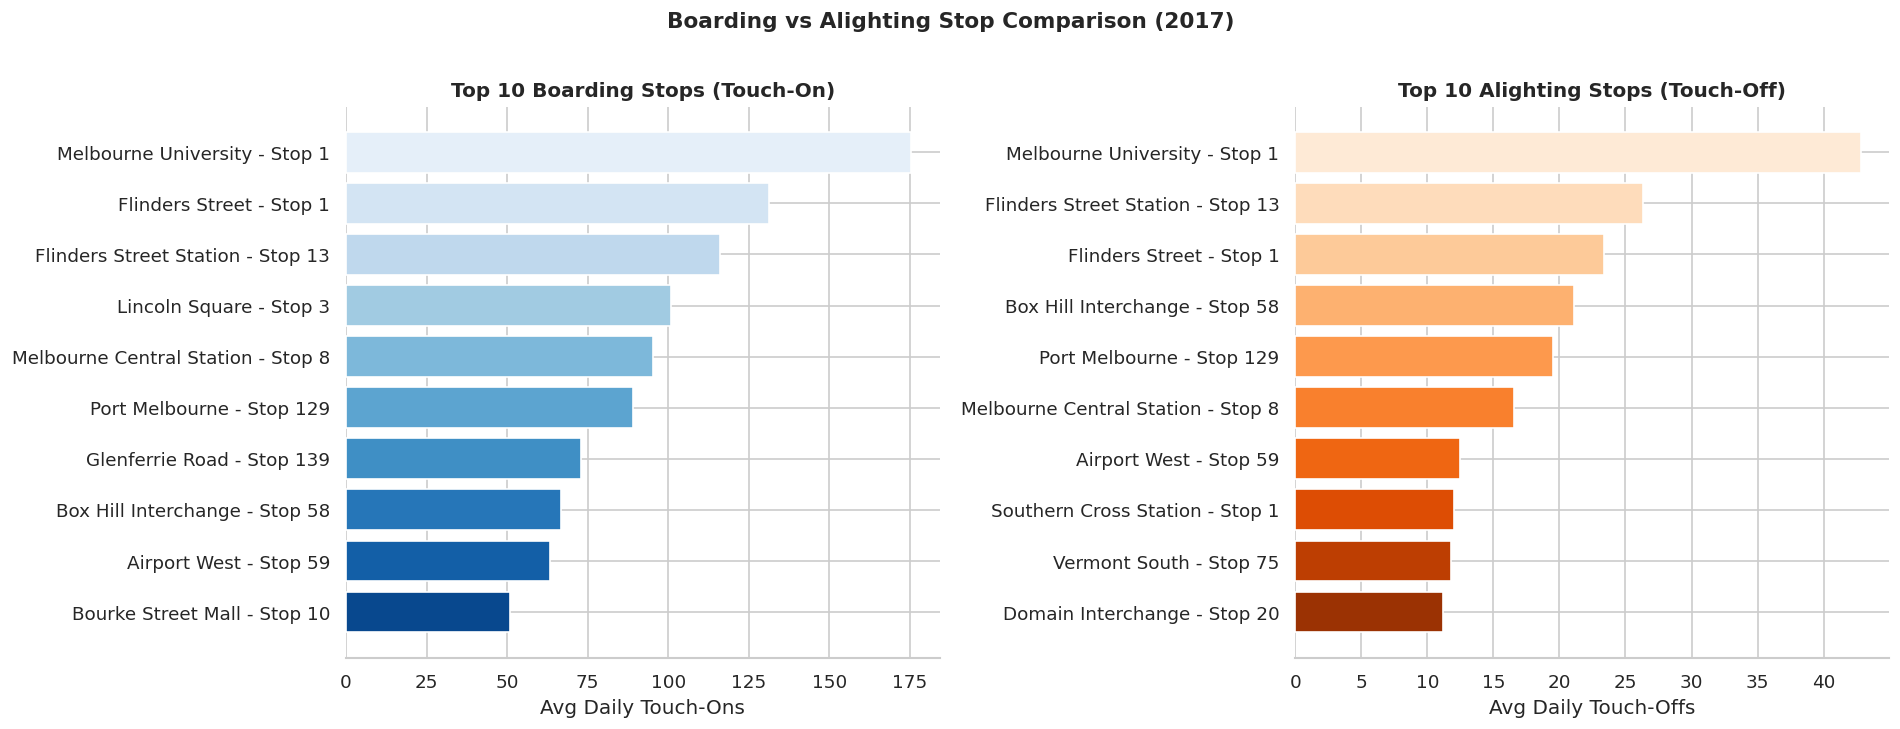

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Touch-on top 10 (reuse avg_stop from Q2)
axes[0].barh(avg_stop['on_stop_name'][::-1], avg_stop['avg_daily_touchons'][::-1],
             color=sns.color_palette('Blues_r', 10))
axes[0].set_title('Top 10 Boarding Stops (Touch-On)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Avg Daily Touch-Ons')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}'))

# Touch-off top 10
axes[1].barh(avg_off['off_stop_name'][::-1], avg_off['avg_daily_touchoffs'][::-1],
             color=sns.color_palette('Oranges_r', 10))
axes[1].set_title('Top 10 Alighting Stops (Touch-Off)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Avg Daily Touch-Offs')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}'))

for ax in axes:
    sns.despine(ax=ax, left=True)

plt.suptitle('Boarding vs Alighting Stop Comparison (2017)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('portfolio_alight_stops.png', dpi=150, bbox_inches='tight')
plt.show()

The side-by-side comparison highlights the strong symmetry between boarding and alighting hubs. Melbourne University Stop 1 leads both charts, confirming its role as a true two-way interchange. The scale difference between the two panels (boarding values ~4× higher) reflects the low touch-off rate, not a genuine asymmetry in passenger flows.

### Analysis 10 — Peak vs Off-Peak Travel Time by Route

To understand whether peak congestion affects journey duration on a per-route basis, we compare the average travel time of trips made during peak windows (07:00–09:00 and 16:00–18:00) against those made at all other times. A positive difference would indicate peak-hour slowdowns; a negative difference would suggest shorter peak trips driven by passenger composition.

In [72]:
trips_tt = trips[trips['travel_time_min'].between(1, 180)].copy()
trips_tt['period'] = trips_tt['hour'].apply(
    lambda h: 'peak' if h in [7, 8, 9, 16, 17, 18] else 'off_peak'
)

peak_tt = (
    trips_tt.groupby(['parent_route', 'period'])['travel_time_min']
    .mean().unstack().reset_index()
)
peak_tt.columns = ['route', 'off_peak_min', 'peak_min']
peak_tt['diff_min'] = (peak_tt['peak_min'] - peak_tt['off_peak_min']).round(2)
peak_tt = peak_tt.sort_values('diff_min')
print(peak_tt.to_string(index=False))

 route  off_peak_min  peak_min  diff_min
    67         42.00     38.22     -3.78
    55         41.74     37.97     -3.76
    58         43.23     39.52     -3.70
   109         46.31     42.65     -3.66
    12         42.98     39.68     -3.30
     1         41.47     38.20     -3.28
    19         44.43     41.34     -3.09
    96         41.04     38.11     -2.93
     6         39.86     37.01     -2.85
    59         43.59     40.90     -2.69
    72         40.92     38.46     -2.47
    75         47.57     45.90     -1.66
    70         43.10     41.47     -1.63
    57         42.71     41.11     -1.60
    16         41.01     39.74     -1.26
    64         39.49     38.56     -0.93
     5         37.72     36.84     -0.88
    48         43.25     42.57     -0.68
     3         39.55     38.93     -0.62
    86         45.68     45.36     -0.33


**Results:** Peak vs off-peak average travel time per route:

| Route | Off-Peak (min) | Peak (min) | Difference |
|-------|---------------|-----------|------------|
| Route 67 | 42.0 | 38.2 | **−3.78** |
| Route 55 | 41.7 | 38.0 | −3.76 |
| Route 58 | 43.2 | 39.5 | −3.70 |
| Route 109 | 46.3 | 42.7 | −3.66 |
| Route 19 | 44.4 | 41.3 | −3.09 |
| ... | ... | ... | ... |
| Route 86 | 45.7 | 45.4 | **−0.33** |

**Every single route shows shorter average travel times during peak hours than during off-peak periods.** The difference ranges from −3.78 minutes (Route 67) to just −0.33 minutes (Route 86). This is a consistent composition effect: during peak hours, the majority of passengers are making targeted commuter trips of moderate length, whereas off-peak travellers include more end-to-end riders making full-route journeys. Route 86 shows the smallest difference (−0.33 min), suggesting its passenger mix is relatively uniform across the day. This finding has practical implications: peak-hour service scheduling should not assume journey times will be longer due to crowding — the data suggests the opposite.

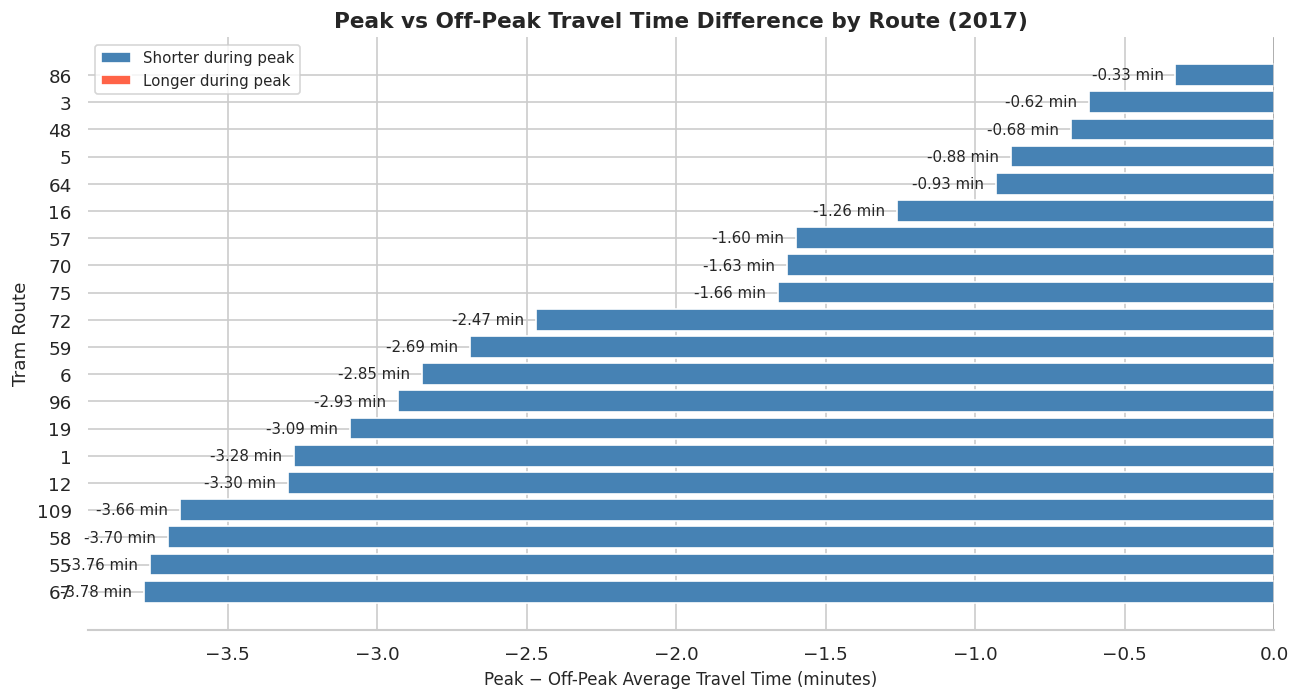

In [73]:
fig, ax = plt.subplots(figsize=(11, 6))
colors = ['steelblue' if d < 0 else 'tomato' for d in peak_tt['diff_min']]
bars = ax.barh(peak_tt['route'].astype(str), peak_tt['diff_min'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
for bar in bars:
    w  = bar.get_width()
    ha = 'right' if w < 0 else 'left'
    offset = -0.04 if w < 0 else 0.04
    ax.text(w + offset, bar.get_y() + bar.get_height()/2,
            f'{w:+.2f} min', va='center', ha=ha, fontsize=9)
ax.set_xlabel('Peak − Off-Peak Average Travel Time (minutes)', fontsize=10)
ax.set_ylabel('Tram Route', fontsize=11)
ax.set_title('Peak vs Off-Peak Travel Time Difference by Route (2017)',
             fontsize=13, fontweight='bold')
legend_elements = [Patch(facecolor='steelblue', label='Shorter during peak'),
                   Patch(facecolor='tomato',    label='Longer during peak')]
ax.legend(handles=legend_elements, fontsize=9)
sns.despine(left=True)
plt.tight_layout()
plt.savefig('portfolio_peak_tt.png', dpi=150, bbox_inches='tight')
plt.show()

All bars fall to the left of the zero line, confirming that peak-hour trips are universally shorter on average. Route 86's near-zero bar distinguishes it as the route least affected by time-of-day composition effects, while Routes 67 and 55 show the most pronounced peak-shortening effect.

## 8. Conclusion

This analysis of **1,904,721 Myki touch-on transactions** across Melbourne's 20 busiest tram routes in 2017 has produced several operationally significant findings. **Melbourne University Stop 1** (175.5 average daily touch-ons, 34% ahead of second place) and **Route 109** (599 average daily passengers, 65% ahead of second place) are the clear network leaders. The end-to-end travel time analysis identified Route 75 as the longest route at a mean of 46.9 minutes, though the narrow 5.3-minute spread across the top 10 suggests broadly comparable physical extents. Hourly demand analysis confirmed a consistent bimodal commuter pattern: the morning peak centres on 08:00 (avg 24.3 touch-ons) and the afternoon peak on 17:00 (avg 26.4), with the afternoon window averaging 13.7% more demand than its morning counterpart.

The most operationally interesting finding is **Route 59's reversed peak pattern** — the only route where morning boardings (96.8/day) substantially exceed afternoon boardings (80.5/day, a −16.8% swing), indicating a strongly directional commuter flow. Routes 67 and 5 exhibit near-neutral peak balance. Natural extensions of this work include weekday vs weekend demand disaggregation, which would likely reveal a much flatter midday profile on Saturdays and Sundays; enriching the dataset with official stop-sequence data to enable distance-based route length estimates; and constructing origin-destination matrices from matched touch-on/touch-off pairs to map spatial passenger flows across the network.